<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>가격지수 전처리 파이프라인 전체 목적</mark></b></span><br><br>

<b>[전체 목적]</b><br>
• GPU, CPU, RAM의 2024년 3월부터 2026년 3월까지의 일별 가격 데이터를 그대로 평균내지 않고, <b>제품별 가격변화율 기반 가격지수</b>로 변환하는 것이 목적<br>
• 제품 출시, 단종, 품절, 수집 누락처럼 제품 구성이 계속 바뀌는 상황에서도 <b>같은 제품의 순수한 가격 변화</b>만 추적하도록 설계<br>
• 최종 산출물은 <b>GPU 전체 지수, CPU 전체 지수, RAM 전체 지수, GPU 성능군별 지수</b>이며, 가설검정에서는 가격 수준이 아니라 <b>관측 가능한 인접 주간 로그수익률</b>을 사용<br><br>

<b>[이 노트북의 입력 전제]</b><br>
• 이 노트북은 원본 크롤링 파일을 바로 읽는 코드가 아니라, 앞 단계의 <b>data_preprocessing.ipynb</b>에서 생성된 <b>processed_*.csv</b>를 입력으로 사용<br>
• GPU는 1차 처리에서 날짜 컬럼명이 YYYY-MM-DD로 정리되고, <b>gpu_model, capacity, tail_paren, name_rest</b>가 생성되며, gpu_model을 찾지 못한 행은 제거됨<br>
• CPU는 1차 처리에서 날짜 셀이 <b>판매형태_가격</b>에서 숫자 가격으로 변환되고, <b>cpu_model, cpu_codename, sale_info</b>가 생성됨<br>
• RAM은 1차 처리에서 한 제품 안의 여러 용량 옵션이 <b>용량별 행</b>으로 풀리고, 날짜 셀이 숫자 가격으로 변환되며, <b>capacity, capacity_gb</b>가 생성됨<br><br>

<b>[전체 파이프라인]</b><br>
• 1단계: processed 데이터 로드 및 실제 가격 행렬 구성<br>
&nbsp;&nbsp;→ 월별 파일을 세로로 붙인 뒤 날짜 컬럼 추출, 0 또는 비가격 상태값 NaN 처리, GPU/CPU/RAM 분석 표본 필터링<br>
• 2단계: 제품별 주간 대푯값 산출<br>
&nbsp;&nbsp;→ GPU/CPU는 Id, RAM은 Id+capacity를 제품 key로 두고 중복 row를 median으로 병합한 뒤 weekly median 계산<br>
• 3단계: Chain Matched Jevons Index 산출<br>
&nbsp;&nbsp;→ 지수 레벨은 단절 시 마지막 유효 주와 현재 주를 bridge하여 복구하되, bridge 수익률은 검정용 주간 수익률에서 제외<br>
• 4단계: 지수 유효성 검증 및 최종 변수 셋업<br>
&nbsp;&nbsp;→ matched product 수, valid ratio, bridge week, flat week, jump week를 점검하고 가설검정용 데이터셋 저장<br><br>

<span style="color: #e53e3e; font-size: 18px;"><b>핵심: 1차 전처리에서 이미 정리된 구조를 신뢰하고, 분석 단계에서는 지수 레벨과 검정용 수익률을 분리해 처리한다.</b></span>
</div>

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>EDA 실행결과 해석 기준</mark></b></span><br><br>
<b>[무엇을 확인했는가]</b><br>
이 노트북은 원시 가격표를 검정 가능한 주간 가격지수와 수익률로 바꾸는 단계이다. 핵심 처리는 0값을 관측 불가능 상태로 보고 제외, 중복 제품의 날짜별 median 병합, 주간 median 가격 생성, 인접 주에 동시에 관측된 동일 제품만 연결하는 Chain Matched Jevons Index 산출이다.<br><br>
<b>[실행결과 기준]</b><br>
최종 EDA 결과에서 전체 지수는 109개 주간 step 중 106개가 valid였고, return 기준 105주가 분석 가능했다. median matched product는 GPU 711개, CPU 209개, RAM 1156개였으며, chip 성능군도 high 269개, mid 316개, low 43개 수준으로 구성되었다. low 그룹은 표본이 작아 해석 주의가 필요하지만, 성능군별 검정 자체는 가능한 수준으로 판단하였다.<br><br>
<b>[그림 저장]</b><br>
이 노트북에서 생성되는 plot은 상대경로 <code>output_pic/</code>에 자동 저장된다. 파일명은 plot title을 기반으로 생성된다.
</div>

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


START_DATE = "2024-03-01"
END_DATE = "2026-03-31"

BASE_INDEX = 100.0
WEEKLY_FREQ = "W-SUN"
WEEKLY_AGG = "median"
AGG_CHECK = ["median", "last"]

MIN_DAYS = 3

RET_Q = 0.05
RET_MIN = 20
RET_MAX = np.log(1.8)

MIN_ALL = 10
MIN_GRP = 3

ROOT = Path(".")
OUT = Path("outputs")
OUT.mkdir(parents=True, exist_ok=True)

DATE_RE = re.compile(r"^\d{4}-\d{2}-\d{2}$")

SPECS = {
    "CPU": {
        "folder": ROOT / "CPU_PREPARE",
        "pattern": "processed_*_CPU.csv",
        "merge_cols": ["Id", "Name", "cpu_model", "cpu_codename", "sale_info"],
    },
    "GPU": {
        "folder": ROOT / "GPU_PREPARE",
        "pattern": "processed_*_GPU.csv",
        "merge_cols": ["Id", "Name", "gpu_model", "capacity", "tail_paren", "name_rest"],
    },
    "RAM": {
        "folder": ROOT / "RAM_PREPARE",
        "pattern": "processed_*_RAM.csv",
        "merge_cols": ["Id", "Name", "ram_model", "memory_gen", "memory_speed", "cl_value", "capacity", "capacity_gb"],
    },
}


def load_files(folder, pattern, merge_cols):
    files = sorted(Path(folder).glob(pattern))
    if len(files) == 0:
        raise FileNotFoundError(f"processed 파일을 찾지 못했습니다: {folder / pattern}")

    frames = []
    for f in files:
        df = pd.read_csv(f)
        df.columns = [str(c).strip().replace("\ufeff", "") for c in df.columns]
        df = df.loc[:, ~df.columns.astype(str).str.match(r"^Unnamed")]
        frames.append(df)

    raw = pd.concat(frames, ignore_index=True, sort=False)

    meta = pd.DataFrame({
        "file_n": [len(files)],
        "row_n": [len(raw)],
        "col_n": [raw.shape[1]],
    })
    return raw, meta


def load_report(df, meta_cols):
    date_cols = [c for c in df.columns if DATE_RE.fullmatch(str(c).strip())]
    valid_counts = df[date_cols].notna().sum(axis=1) if date_cols else pd.Series(0, index=df.index)
    return pd.DataFrame({
        "row_n": [len(df)],
        "date_n": [len(date_cols)],
        "max_obs": [valid_counts.max()],
        "full_row_n": [(valid_counts == valid_counts.max()).sum()],
    })


raw_C, meta_C = load_files(**SPECS["CPU"])
raw_G, meta_G = load_files(**SPECS["GPU"])
raw_R, meta_R = load_files(**SPECS["RAM"])

for name, raw, meta in [("CPU", raw_C, meta_C), ("GPU", raw_G, meta_G), ("RAM", raw_R, meta_R)]:
    print(f"[{name}] files: {meta.loc[0, 'file_n']} / rows: {len(raw)} / cols: {raw.shape[1]}")
    display(load_report(raw, SPECS[name]["merge_cols"]))
    display(raw.head(3))

import re as _re
from datetime import datetime as _dt

FIG_DIR = ROOT / "output_pic"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def _safe_fname(text, max_len=120):
    text = str(text).strip()
    text = _re.sub(r"[\\/:*?\"<>|]+", "_", text)
    text = _re.sub(r"\s+", "_", text)
    text = _re.sub(r"_+", "_", text).strip("._ ")
    if not text:
        text = "plot"
    return text[:max_len]

def _infer_title(fig=None):
    fig = fig or plt.gcf()
    if getattr(fig, "_suptitle", None) is not None:
        t = fig._suptitle.get_text()
        if t:
            return t
    for ax in fig.axes:
        t = ax.get_title()
        if t:
            return t
    for ax in fig.axes:
        ylabel = ax.get_ylabel()
        xlabel = ax.get_xlabel()
        if ylabel or xlabel:
            return f"{ylabel}_vs_{xlabel}".strip("_vs_")
    return "plot_" + _dt.now().strftime("%Y%m%d_%H%M%S")

def save_plot(name=None, folder=None, dpi=300):
    folder = Path(folder) if folder is not None else FIG_DIR
    folder.mkdir(parents=True, exist_ok=True)
    fig = plt.gcf()
    title = name or _infer_title(fig)
    stem = _safe_fname(title)
    path = folder / f"{stem}.png"
    i = 2
    while path.exists():
        path = folder / f"{stem}_{i:02d}.png"
        i += 1
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"[saved plot] {path}")
    return path

[CPU] files: 25 / rows: 11542 / cols: 762


,row_n,date_n,max_obs,full_row_n
0,11542,757,31,6427


,Id,Name,cpu_model,cpu_codename,sale_info,2024-03-01,2024-03-02,2024-03-03,2024-03-04,2024-03-05,...,2026-03-22,2026-03-23,2026-03-24,2026-03-25,2026-03-26,2026-03-27,2026-03-28,2026-03-29,2026-03-30,2026-03-31
0,15833261,AMD A4 3300 (라노),AMD A4 3300,라노,중고,0.0,0.0,0.0,5000.0,5000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15834833,AMD A4 3400 (라노),AMD A4 3400,라노,중고,5490.0,5490.0,5490.0,0.0,5490.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,18170813,AMD A4 7300 (리치랜드),AMD A4 7300,리치랜드,중고,9490.0,9490.0,9490.0,9490.0,9490.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[GPU] files: 25 / rows: 24201 / cols: 763


,row_n,date_n,max_obs,full_row_n
0,24201,757,31,13512


,Id,Name,2024-03-01,2024-03-02,2024-03-03,2024-03-04,2024-03-05,2024-03-06,2024-03-07,2024-03-08,...,2026-03-22,2026-03-23,2026-03-24,2026-03-25,2026-03-26,2026-03-27,2026-03-28,2026-03-29,2026-03-30,2026-03-31
0,36709217,AFOX 라데온 RX 580 2048SP D5 8GB 대원씨티에스,"119,760","119,760","119,760","119,760","118,560","118,540","118,470","119,760",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,36709184,AFOX 지포스 GTX 1650 D6 4GB 대원씨티에스,"190,070","190,070","190,070","190,070","187,280","187,190","187,080","190,570",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19355444,AFOX 지포스 GTX 1650 H1 D6 4GB DUAL 디앤디컴,"201,680","201,680","201,680","201,680","214,000","214,000","214,000","214,000",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


[RAM] files: 25 / rows: 53170 / cols: 765


,row_n,date_n,max_obs,full_row_n
0,53170,757,31,29497


,Id,Name,ram_model,memory_gen,memory_speed,cl_value,capacity,capacity_gb,2024-03-01,2024-03-02,...,2026-03-22,2026-03-23,2026-03-24,2026-03-25,2026-03-26,2026-03-27,2026-03-28,2026-03-29,2026-03-30,2026-03-31
0,11830747,ADATA DDR4-3200 CL22,ADATA,DDR4,3200,CL22,32GB,32,91000.0,91000.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11830747,ADATA DDR4-3200 CL22,ADATA,DDR4,3200,CL22,16GB,16,41790.0,41760.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,11830747,ADATA DDR4-3200 CL22,ADATA,DDR4,3200,CL22,8GB,8,21150.0,21150.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>1단계: processed 데이터 로드 및 실제 가격 행렬 구성</mark></b></span><br><br>

<b>[수행 목적]</b><br>
• 이 단계에서는 원본 크롤링 문자열을 다시 해체하지 않고, 1차 처리 결과를 입력으로 받아 분석에 필요한 가격 행렬만 구성<br>
• 날짜 컬럼은 이미 YYYY-MM-DD 형식으로 정리되어 있으므로, 해당 패턴과 일치하는 컬럼만 가격 시계열로 사용<br><br>

<b>[가격값 처리]</b><br>
• CPU와 RAM은 1차 처리에서 날짜 셀이 이미 숫자 가격으로 변환되어 있음<br>
• GPU는 1차 처리에서 메타데이터가 분리되었지만 날짜 셀에는 콤마가 포함된 가격 문자열이나 일시품절 같은 상태값이 남아 있을 수 있음<br>
• 따라서 분석 단계에서는 모든 날짜 컬럼에 대해 콤마만 제거하고 숫자형으로 변환한 뒤, 숫자로 바뀌지 않는 상태값과 0 이하 가격을 NaN 처리<br><br>

<b>[결측치 처리 원칙]</b><br>
• 가격 결측은 앞뒤 날짜로 임의 보간하지 않음<br>
• 보간을 하면 실제 시장에서 관측되지 않은 가상의 가격이 생성되어 BTC와의 상관분석 또는 회귀분석을 왜곡할 수 있음<br>
• 결측은 결측으로 남기고, 이후 <b>weekly median</b>과 <b>matched sample</b> 방식으로 불규칙 관측 문제를 완화<br><br>

<span style="color: #e53e3e; font-size: 18px;"><b>핵심: 여기서는 raw 파싱을 반복하지 않고, 1차 처리된 가격표에서 실제 관측 가격만 숫자 행렬로 만든다.</b></span>
</div>

In [2]:
def get_dates(df, start=START_DATE, end=END_DATE):
    date_cols = sorted(c for c in df.columns if DATE_RE.fullmatch(str(c)))
    return [c for c in date_cols if start <= c <= end]


def price_mat(df, date_cols):
    X = df.loc[:, date_cols].replace(",", "", regex=True)
    X = X.apply(pd.to_numeric, errors="coerce")
    return X.where(X > 0).astype(float)


g_dates = get_dates(raw_G)
c_dates = get_dates(raw_C)
r_dates = get_dates(raw_R)

for name, dates in [("GPU", g_dates), ("CPU", c_dates), ("RAM", r_dates)]:
    print(f"{name}: {len(dates)} date columns ({dates[0]} ~ {dates[-1]})")

price_check = pd.DataFrame({
    "dataset": ["GPU", "CPU", "RAM"],
    "rows": [len(raw_G), len(raw_C), len(raw_R)],
    "date_cols": [len(g_dates), len(c_dates), len(r_dates)],
    "non_missing_price_cells": [
        price_mat(raw_G, g_dates).notna().sum().sum(),
        price_mat(raw_C, c_dates).notna().sum().sum(),
        price_mat(raw_R, r_dates).notna().sum().sum(),
    ],
})
display(price_check)

GPU: 757 date columns (2024-03-01 ~ 2026-03-31)
CPU: 757 date columns (2024-03-01 ~ 2026-03-31)
RAM: 757 date columns (2024-03-01 ~ 2026-03-31)


,dataset,rows,date_cols,non_missing_price_cells
0,GPU,24201,757,621172
1,CPU,11542,757,294336
2,RAM,53170,757,974913


In [4]:
def date_gap(date_cols, name):
    observed = pd.to_datetime(date_cols)
    full = pd.date_range(observed.min(), observed.max(), freq="D")
    missing = full.difference(observed)

    report = pd.DataFrame({
        "dataset": [name],
        "observed_days": [len(observed)],
        "full_calendar_days": [len(full)],
        "missing_calendar_days": [len(missing)],
        "missing_ratio": [len(missing) / len(full)],
    })

    missing_weekday = (
        pd.Series(missing.day_name()).value_counts().rename_axis("weekday").reset_index(name="missing_cnt")
        if len(missing) else pd.DataFrame(columns=["weekday", "missing_cnt"])
    )
    return report, missing_weekday


for name, dates in [("GPU", g_dates), ("CPU", c_dates), ("RAM", r_dates)]:
    report, missing_weekday = date_gap(dates, name)
    display(report)
    display(missing_weekday)

,dataset,observed_days,full_calendar_days,missing_calendar_days,missing_ratio
0,GPU,757,761,4,0.005256


,weekday,missing_cnt
0,Saturday,2
1,Sunday,1
2,Monday,1


,dataset,observed_days,full_calendar_days,missing_calendar_days,missing_ratio
0,CPU,757,761,4,0.005256


,weekday,missing_cnt
0,Saturday,2
1,Sunday,1
2,Monday,1


,dataset,observed_days,full_calendar_days,missing_calendar_days,missing_ratio
0,RAM,757,761,4,0.005256


,weekday,missing_cnt
0,Saturday,2
1,Sunday,1
2,Monday,1


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>GPU 메타데이터 정리 및 성능군 분류</mark></b></span><br><br>

<b>[1차 처리 결과를 어떻게 활용하는가]</b><br>
• data_preprocessing 단계에서 이미 <b>gpu_model</b>과 <b>capacity</b>가 분리되어 있으므로, 여기서는 제품명을 다시 복잡하게 파싱하지 않음<br>
• VRAM은 capacity 컬럼에서 GB/MB 단위를 숫자로 바꾸고, 칩셋은 gpu_model에서 RTX, GTX, RX, ARC 계열명만 정규화<br><br>

<b>[칩셋 기준 성능군]</b><br>
• H2는 <b>GPU 성능군별로 BTC 가격변동에 대한 민감도가 다른가</b>를 보는 가설<br>
• 따라서 GPU 전체를 하나로 평균내지 않고 <b>chip_perf_group = low / mid / high</b>를 생성<br>
• workstation 계열이나 칩셋 해석이 애매한 행은 H2 본분석 표본에서 제외<br><br>

<b>[VRAM proxy 성능군]</b><br>
• 칩셋 기준 분류가 본분석이며, VRAM 기준 low/mid/high는 결과의 강건성을 확인하는 보조분석용 proxy<br>
• VRAM proxy는 성능 그 자체가 아니라 고용량 제품군을 근사하는 보조 기준으로만 해석<br><br>

<span style="color: #e53e3e; font-size: 18px;"><b>핵심: 1차 처리에서 이미 추출된 gpu_model과 capacity를 신뢰하고, 분석 단계에서는 성능군 분류만 최소한으로 수행한다.</b></span>
</div>

In [3]:
def cap_gb(capacity):
    text = str(capacity).upper().replace(" ", "")
    if text in {"", "0", "NAN", "NONE"}:
        return np.nan

    gb = re.search(r"(\d+(?:\.\d+)?)GB", text)
    if gb:
        return float(gb.group(1))

    mb = re.search(r"(\d+(?:\.\d+)?)MB", text)
    if mb:
        return float(mb.group(1)) / 1024

    g_only = re.search(r"(\d+(?:\.\d+)?)G$", text)
    if g_only:
        return float(g_only.group(1))

    return np.nan


def get_chip(model):
    text = re.sub(r"\s+", " ", str(model).upper()).strip()
    text = text.replace("GEFORCE", "").replace("지포스", "")
    text = text.replace("RADEON", "").replace("라데온", "")
    text = re.sub(r"\s+", " ", text).strip()

    patterns = [
        (r"\bRTX\s*A\s?(\d{4})\b", lambda m: f"RTX A{m.group(1)}"),
        (r"\bPRO\s*W\s?(\d{4})\b", lambda m: f"PRO W{m.group(1)}"),
        (r"\bRTX\s*(\d{4})\s*(TI)?\s*(SUPER)?", lambda m: f"RTX {m.group(1)} {' '.join(x for x in [m.group(2), m.group(3)] if x)}".strip()),
        (r"\bGTX\s*(\d{3,4})\s*(TI)?\s*(SUPER)?", lambda m: f"GTX {m.group(1)} {' '.join(x for x in [m.group(2), m.group(3)] if x)}".strip()),
        (r"\bGT\s*(\d{3,4})\b", lambda m: f"GT {m.group(1)}"),
        (r"\bRX\s*(\d{3,4})\s*(XTX|XT|GRE)?", lambda m: f"RX {m.group(1)} {m.group(2) or ''}".strip()),
        (r"\bARC\s*A\s?(\d{3,4})\b", lambda m: f"ARC A{m.group(1)}"),
    ]

    for pattern, formatter in patterns:
        match = re.search(pattern, text)
        if match:
            return formatter(match)
    return np.nan


def chip_group(chip):
    chip = str(chip).upper().strip()
    if chip in {"", "NAN", "NONE"}:
        return "unknown"

    if any(x in chip for x in ["RTX A", "QUADRO", "TESLA", "PRO W"]):
        return "workstation"

    rtx = re.search(r"\bRTX\s*(\d{4})\b", chip)
    if rtx:
        tier = int(rtx.group(1)) % 100
        if tier >= 80:
            return "high"
        if tier == 70:
            return "high" if ("TI" in chip or "SUPER" in chip) else "mid"
        return "mid" if tier == 60 else "low"

    gtx = re.search(r"\bGTX\s*(\d{3,4})\b", chip)
    if gtx:
        return "mid" if int(gtx.group(1)) >= 1660 else "low"

    if re.search(r"\bGT\s*(\d{3,4})\b", chip):
        return "low"

    rx = re.search(r"\bRX\s*(\d{3,4})\b", chip)
    if rx:
        num = int(rx.group(1))
        tier = num % 100 if num >= 9000 else ((num // 100) % 10) * 10
        if tier >= 80:
            return "high"
        if tier == 70:
            return "high" if any(x in chip for x in ["XTX", "XT", "GRE"]) else "mid"
        return "mid" if tier == 60 else "low"

    arc = re.search(r"\bARC\s*A\s?(\d{3,4})\b", chip)
    if arc:
        return "mid" if int(arc.group(1)) in {770, 750, 580} else "low"

    return "unknown"


def vram_group(vram_gb):
    if pd.isna(vram_gb) or vram_gb <= 0:
        return "unknown"
    if vram_gb >= 12:
        return "high"
    return "mid" if vram_gb > 6 else "low"


EX_GPU = r"노트북|모바일|LAPTOP|MOBILE|MAX-Q|NOTEBOOK"

def prep_gpu(gpu_df):
    g = gpu_df.copy()

    text_cols = [c for c in ["Name", "gpu_model", "name_rest"] if c in g.columns]
    txt = g[text_cols].fillna("").astype(str).agg(" ".join, axis=1)
    g = g[~txt.str.contains(EX_GPU, case=False, regex=True, na=False)].copy()

    g["vram_gb"] = g["capacity"].apply(cap_gb)
    g["gpu_chip_clean"] = g["gpu_model"].apply(get_chip)
    g["chip_perf_group"] = g["gpu_chip_clean"].apply(chip_group)
    g["h2_perf_group"] = g["vram_gb"].apply(vram_group)
    return g


gpu_meta = prep_gpu(raw_G)
gpu_cards = gpu_meta[gpu_meta["chip_perf_group"].isin(["low", "mid", "high"]) & gpu_meta["vram_gb"].notna()].copy()

print("GPU rows after 1st preprocessing:", len(raw_G))
print("GPU rows used in main analysis:", len(gpu_cards))

print("chip_perf_group, main H2 group")
display(gpu_cards["chip_perf_group"].value_counts(dropna=False))

print("h2_perf_group, VRAM proxy")
display(gpu_cards["h2_perf_group"].value_counts(dropna=False))

print("chip group vs VRAM proxy")
display(pd.crosstab(gpu_cards["chip_perf_group"], gpu_cards["h2_perf_group"]))

audit_cols = ["Id", "Name", "gpu_model", "capacity", "vram_gb", "gpu_chip_clean", "chip_perf_group", "h2_perf_group"]
display(gpu_cards[audit_cols].head(20))

GPU rows after 1st preprocessing: 24201
GPU rows used in main analysis: 20059
chip_perf_group, main H2 group


chip_perf_group
mid     9803
high    8911
low     1345
Name: count, dtype: int64

h2_perf_group, VRAM proxy


h2_perf_group
high    11360
mid      7084
low      1615
Name: count, dtype: int64

chip group vs VRAM proxy


h2_perf_group,high,low,mid
chip_perf_group,,,
high,8359,0,552
low,0,874,471
mid,3001,741,6061


,Id,Name,gpu_model,capacity,vram_gb,gpu_chip_clean,chip_perf_group,h2_perf_group
0,36709217,AFOX 라데온 RX 580 2048SP D5 8GB 대원씨티에스,RX 580 2048SP,8GB,8.0,RX 580,low,mid
1,36709184,AFOX 지포스 GTX 1650 D6 4GB 대원씨티에스,GTX 1650,4GB,4.0,GTX 1650,low,low
2,19355444,AFOX 지포스 GTX 1650 H1 D6 4GB DUAL 디앤디컴,GTX 1650,4GB,4.0,GTX 1650,low,low
3,31374095,AFOX 지포스 GTX 1650 H3 D6 4GB DUAL 디앤디컴,GTX 1650,4GB,4.0,GTX 1650,low,low
4,19347545,AFOX 지포스 GTX 1660 SUPER H4 D6 6GB DUAL 디앤디컴,GTX 1660 SUPER,6GB,6.0,GTX 1660 SUPER,mid,low
5,21538871,AFOX 지포스 RTX 3080 Ti D6X 12GB 대원씨티에스,RTX 3080 Ti,12GB,12.0,RTX 3080 TI,high,high
14,10427364,ARKTEK 지포스 GTX 1660 SUPER D6 6GB,GTX 1660 SUPER,6GB,6.0,GTX 1660 SUPER,mid,low
16,39251951,ASL 지포스 RTX 4070 SUPER RAGE-X WHITE D6X 12GB DUAL,RTX 4070 SUPER,12GB,12.0,RTX 4070 SUPER,high,high
18,16234694,ASRock Phantom Gaming D 라데온 RX 6500 XT OC D6 4...,RX 6500 XT,4GB,4.0,RX 6500 XT,low,low
19,16248074,ASRock Phantom Gaming D 라데온 RX 6500 XT OC D6 4...,RX 6500 XT,4GB,4.0,RX 6500 XT,low,low


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>2단계: 제품별 중복 병합 및 주간 대푯값 산출</mark></b></span><br><br>

<b>[동일 제품 식별 기준]</b><br>
• GPU와 CPU는 1차 처리 후에도 제품 단위가 <b>Id</b>로 대응되므로 Id를 제품 key로 사용<br>
• RAM은 1차 처리에서 한 Id 안의 여러 용량 옵션을 별도 행으로 확장했으므로, <b>Id 하나로 병합하면 서로 다른 용량 가격이 섞이는 오류</b>가 발생할 수 있음<br>
• 따라서 RAM은 <b>Id + capacity</b>를 제품 key로 사용하여 같은 제품의 같은 용량 옵션만 하나의 시계열로 병합<br><br>

<b>[중복 가격 병합]</b><br>
• 월별 파일 병합 과정에서 같은 제품 key가 여러 행으로 남을 수 있으므로 날짜별 가격은 median으로 병합<br>
• mean이 아니라 median을 쓰는 이유는 일시적 가격 튐이나 판매처 차이에 따른 극단값 영향을 줄이기 위함<br>
• 중복 가격 spread 진단은 전체 데이터를 한 번에 long-form으로 펼치지 않고, 날짜별로 필요한 요약값만 계산해 메모리 사용을 줄임<br><br>

<b>[왜 주간 데이터로 변환하는가]</b><br>
• 쇼핑몰 하드웨어 가격은 매일 균일하게 관측되는 금융자산 가격과 다름<br>
• 특정 날짜에는 수집 공백, 품절, 일부 판매처 가격만 반영되는 문제가 있으므로, 본분석에서는 제품별 <b>weekly median</b>을 사용<br>
• weekly last는 본분석이 아니라 민감도 분석에서만 비교<br><br>

<span style="color: #e53e3e; font-size: 18px;"><b>핵심: RAM은 Id 단독 병합이 아니라 Id+capacity 병합이 맞고, 제품별 주간 대표가격은 weekly median으로 산출한다.</b></span>
</div>

In [4]:
KEYS = {
    "GPU": ["Id"],
    "CPU": ["Id"],
    "RAM": ["Id", "capacity"],
}


def dup_spread(df, date_cols, key_cols, top=20):
    X = price_mat(df, date_cols)
    keys = df[key_cols].reset_index(drop=True).copy()
    parts = []

    for col in date_cols:
        temp = keys.copy()
        temp["price"] = X[col].to_numpy()
        temp = temp.dropna(subset=["price"])
        if temp.empty:
            continue

        spread = (
            temp.groupby(key_cols, dropna=False)["price"]
                .agg(["count", "min", "median", "max"])
                .reset_index()
        )
        spread = spread[spread["count"] >= 2].copy()
        if len(spread) == 0:
            continue

        spread["date"] = col
        spread["max_min_ratio"] = spread["max"] / spread["min"]
        parts.append(spread)

    cols = key_cols + ["date", "count", "min", "median", "max", "max_min_ratio"]
    if len(parts) == 0:
        return pd.DataFrame(columns=cols)

    return (
        pd.concat(parts, ignore_index=True)[cols]
        .sort_values("max_min_ratio", ascending=False)
        .head(top)
    )


def merge_dups(df, date_cols, key_cols):
    X = price_mat(df, date_cols)

    price_agg = (
        pd.concat([df[key_cols].reset_index(drop=True), X.reset_index(drop=True)], axis=1)
        .groupby(key_cols, dropna=False)[date_cols]
        .median()
        .reset_index()
    )

    meta_cols = [c for c in df.columns if c not in date_cols]
    extra_cols = [c for c in meta_cols if c not in key_cols]
    meta_agg = df[key_cols + extra_cols].groupby(key_cols, dropna=False).first().reset_index()
    return meta_agg.merge(price_agg, on=key_cols, how="right")


def filter_cpu(df):
    out = df.copy()
    name = out["Name"].astype(str)
    out = out[~name.str.contains("중고|XEON|EPYC|제온|옵테론", case=False, regex=True, na=False)].copy()
    out = out[~out["sale_info"].astype(str).str.contains("중고", na=False)].copy()
    return out


def filter_ram(df):
    out = df.copy()
    out["capacity_gb"] = pd.to_numeric(out["capacity_gb"], errors="coerce")
    out = out[out["memory_gen"].astype(str).str.upper().isin(["DDR4", "DDR5"])].copy()
    out = out[out["capacity_gb"].notna() & (out["capacity_gb"] > 0)].copy()
    return out


cpu_main = filter_cpu(raw_C)
ram_main = filter_ram(raw_R)

print("duplicate merge keys")
print("GPU:", KEYS["GPU"])
print("CPU:", KEYS["CPU"])
print("RAM:", KEYS["RAM"])

print("GPU duplicate price spread")
display(dup_spread(gpu_cards, g_dates, KEYS["GPU"]))
print("CPU duplicate price spread")
display(dup_spread(cpu_main, c_dates, KEYS["CPU"]))
print("RAM duplicate price spread")
display(dup_spread(ram_main, r_dates, KEYS["RAM"]))

gpu_dedup = merge_dups(gpu_cards, g_dates, KEYS["GPU"])
cpu_dedup = merge_dups(cpu_main, c_dates, KEYS["CPU"])
ram_dedup = merge_dups(ram_main, r_dates, KEYS["RAM"])

print("GPU before/after dedup:", len(gpu_cards), len(gpu_dedup))
print("CPU raw/main/after dedup:", len(raw_C), len(cpu_main), len(cpu_dedup))
print("RAM raw/main/after dedup:", len(raw_R), len(ram_main), len(ram_dedup))

print("GPU chip_perf_group after dedup")
display(gpu_dedup["chip_perf_group"].value_counts(dropna=False))

duplicate merge keys
GPU: ['Id']
CPU: ['Id']
RAM: ['Id', 'capacity']
GPU duplicate price spread


,Id,date,count,min,median,max,max_min_ratio


CPU duplicate price spread


,Id,date,count,min,median,max,max_min_ratio


RAM duplicate price spread


,Id,capacity,date,count,min,median,max,max_min_ratio


GPU before/after dedup: 20059 1979
CPU raw/main/after dedup: 11542 5793 446
RAM raw/main/after dedup: 53170 47788 4288
GPU chip_perf_group after dedup


chip_perf_group
mid     928
high    895
low     156
Name: count, dtype: int64

In [6]:
def cov_table(df, date_cols, group_col=None):
    X = price_mat(df, date_cols)
    out = df.copy()
    out["obs_cnt"] = X.notna().sum(axis=1)
    out["coverage"] = X.notna().mean(axis=1)
    out["first_price_date"] = X.apply(lambda r: r.dropna().index[0] if r.notna().any() else np.nan, axis=1)
    out["last_price_date"] = X.apply(lambda r: r.dropna().index[-1] if r.notna().any() else np.nan, axis=1)

    if group_col is None:
        summary = pd.DataFrame({
            "product_n": [len(out)],
            "median_coverage": [out["coverage"].median()],
            "min_coverage": [out["coverage"].min()],
            "max_coverage": [out["coverage"].max()],
            "median_obs_cnt": [out["obs_cnt"].median()],
        })
    else:
        summary = (
            out.groupby(group_col, dropna=False)
               .agg(
                   product_n=("obs_cnt", "size"),
                   median_coverage=("coverage", "median"),
                   min_coverage=("coverage", "min"),
                   max_coverage=("coverage", "max"),
                   median_obs_cnt=("obs_cnt", "median"),
               )
               .reset_index()
        )
    return out, summary


gpu_cov_detail, gpu_chip_cov_summary = cov_table(gpu_dedup, g_dates, group_col="chip_perf_group")
_, gpu_vram_cov_summary = cov_table(gpu_dedup, g_dates, group_col="h2_perf_group")

print("H2 main: chip group coverage")
display(gpu_chip_cov_summary)
print("H2 auxiliary: VRAM proxy coverage")
display(gpu_vram_cov_summary)

H2 main: chip group coverage


,chip_perf_group,product_n,median_coverage,min_coverage,max_coverage,median_obs_cnt
0,high,895,0.387054,0.0,0.984148,293.0
1,low,156,0.284676,0.0,0.984148,215.5
2,mid,928,0.368560,0.0,0.984148,279.0


H2 auxiliary: VRAM proxy coverage


,h2_perf_group,product_n,median_coverage,min_coverage,max_coverage,median_obs_cnt
0,high,1144,0.387054,0.0,0.984148,293.0
1,low,169,0.273448,0.0,0.984148,207.0
2,mid,666,0.350066,0.0,0.984148,265.0


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>3단계: Weekly Median 및 Chain Matched Jevons Index 산출</mark></b></span><br><br>

<b>[주간 대표가격 산출]</b><br>
일별 가격을 그대로 쓰지 않고, 제품별 주간 중앙값으로 바꾼다. 다만 어떤 주에 가격이 하루만 관측되었는데 그 하루가 특가 또는 수집 오류라면 주간 대표값이 흔들릴 수 있다. 이를 줄이기 위해 이번 코드에서는 제품-주 단위로 <b>최소 3일 이상 가격이 관측된 경우</b>만 weekly median을 유효값으로 인정한다.<br><br>

<b>[핵심 계산 원리]</b><br>
제품군 전체 가격 수준을 단순 평균하지 않고, 인접 주 또는 연결 가능한 기준 주 사이에 <b>동일 제품이 동시에 관측된 경우</b>만 사용한다. 각 제품의 가격 수준이 아니라 로그수익률을 계산한 뒤 이를 평균하여 누적한다. 따라서 비싼 제품이 일시적으로 빠지거나 신제품이 새로 들어오는 구성 변화가 지수에 직접 반영되는 문제를 줄인다.<br><br>

<b>[극단값 처리]</b><br>
로그수익률의 평균은 Jevons Index의 핵심이지만, 크롤링 오류로 특정 제품 가격이 비정상적으로 급등락하면 해당 주의 평균 로그수익률이 왜곡될 수 있다. 따라서 먼저 <b>명백한 오류성 주간 변동</b>을 제거하고, 그 후 매칭 제품 수가 충분한 주에 한해 상하위 5% 로그수익률을 절사한 뒤 평균을 낸다. 표본이 작은 성능군에서는 무리한 분위수 절사를 하지 않되, 오류성 극단값 필터는 동일하게 적용한다. 이는 Jevons의 평균 로그수익률 구조를 유지하면서 수집 오류성 이상치만 완화하기 위한 절충이다.<br><br>

<b>[로그 변환 안전장치]</b><br>
가격 행렬은 price_mat에서 0 이하 값을 NaN 처리하지만, 로그 변환 직전에도 한 번 더 0 이하 값을 제거한다. 따라서 원자료 또는 중간 산출물에 0, 음수, 무한대가 섞여도 -inf가 수익률 계산에 남지 않도록 방어한다.<br><br>

<b>[Bridge 처리]</b><br>
특정 주에 최소 매칭 수를 만족하지 못하면 그 주의 지수값은 유효값으로 쓰지 않는다. 이후 다시 충분한 제품이 관측되면 마지막 유효 주와 현재 주를 직접 매칭해 지수 레벨을 복구한다. 다만 bridge 구간의 수익률은 여러 주에 걸친 누적 변화이므로, 이를 주간 단위로 나누면 변동성이 평활화될 수 있다. 따라서 <b>H1~H3의 상관분석, 회귀, 가설검정에는 bridge 수익률을 사용하지 않고</b>, 인접 주 기준으로 관측된 ret_w만 사용한다.<br><br>

<b>[순차 계산을 유지하는 이유]</b><br>
Chain index는 이전 유효 주가 어디였는지에 따라 다음 anchor가 달라지는 경로 의존 계산이다. 따라서 완전 벡터화보다 짧은 주간 루프가 더 명확하며, 2년치 주간 자료에서는 병목이 되지 않는다.<br><br>

<b>[동일가중의 의미]</b><br>
판매량 데이터가 없기 때문에 Laspeyres 또는 Paasche처럼 거래량 가중 가격지수는 만들지 않는다. 본 분석은 제품별 로그수익률을 동일가중으로 평균한 Jevons Index이므로, 이는 실제 판매액 기준 시장 물가라기보다 <b>관측 가능한 제품군의 전반적 가격 변화</b>를 추적하는 지수로 해석한다. 거래량 가중치를 임의로 추정하거나 리뷰 수를 수요 대리변수로 넣는 방식은 오히려 측정오차를 추가할 수 있으므로 본분석에서는 사용하지 않는다.<br><br>
</div>

In [5]:
def weekly_mat(df, date_cols, freq=WEEKLY_FREQ, agg=WEEKLY_AGG, min_days=MIN_DAYS):
    X = price_mat(df, date_cols).T
    X.index = pd.to_datetime(date_cols)

    obs_n = X.resample(freq).count()
    if agg == "last":
        weekly = X.resample(freq).agg(lambda s: s.dropna().iloc[-1] if s.notna().any() else np.nan)
    else:
        weekly = getattr(X.resample(freq), agg)()

    weekly = weekly.where(obs_n >= min_days)
    weekly = weekly.T
    weekly.columns = [d.strftime("%Y-%m-%d") for d in weekly.columns]
    return weekly, list(weekly.columns)


def log_price(X):
    X = X.astype(float).where(X > 0)
    with np.errstate(divide="ignore", invalid="ignore"):
        out = np.log(X)
    return out.replace([np.inf, -np.inf], np.nan)


def lr_mean(r, q=RET_Q, trim_min=RET_MIN, abs_max=RET_MAX):
    r = pd.Series(r).replace([np.inf, -np.inf], np.nan).dropna()
    n0 = len(r)
    if n0 == 0:
        return np.nan, 0, 0

    if abs_max is not None:
        r = r[r.abs() <= abs_max]

    if len(r) == 0:
        return np.nan, 0, int(n0)

    if q > 0 and len(r) >= trim_min:
        lo, hi = r.quantile([q, 1 - q])
        r2 = r[(r >= lo) & (r <= hi)]
    else:
        r2 = r

    return float(r2.mean()), int(len(r2)), int(n0 - len(r2))


def chain_idx(X, date_cols, group_name="ALL", min_matched=5, base=BASE_INDEX, q=RET_Q):
    logX = log_price(X)
    dates = pd.to_datetime(date_cols)

    idx = float(base)
    anchor = 0

    rows = [{
        "date": dates[0],
        "group": group_name,
        "from_date": pd.NaT,
        "index_ffill": idx,
        "index_valid": idx,
        "log_return": np.nan,
        "ret_lvl": np.nan,
        "ret_w": np.nan,
        "n_matched": 0,
        "n_used": 0,
        "n_trim": 0,
        "n_adj": 0,
        "n_adj_used": 0,
        "n_adj_trim": 0,
        "step_n": 0,
        "interval_days": np.nan,
        "bridge": False,
        "valid_step": True,
        "ret_ok": False,
    }]

    for j in range(1, len(date_cols)):
        adj = logX.iloc[:, j] - logX.iloc[:, j - 1]
        n_adj = int(adj.dropna().shape[0])
        adj_lr, n_adj_used, n_adj_trim = lr_mean(adj, q=q)
        ret_ok = n_adj >= min_matched and n_adj_used >= min_matched
        ret_w = adj_lr if ret_ok else np.nan

        ret = logX.iloc[:, j] - logX.iloc[:, anchor]
        n_matched = int(ret.dropna().shape[0])
        lr, n_used, n_trim = lr_mean(ret, q=q)

        step_n = j - anchor
        interval_days = int((dates[j] - dates[anchor]).days)
        from_date = dates[anchor]

        if n_matched >= min_matched and n_used >= min_matched:
            idx *= np.exp(lr)
            index_valid = idx
            ret_lvl = lr / step_n
            bridge = step_n > 1
            valid_step = True
            anchor = j
        else:
            lr = np.nan
            index_valid = np.nan
            ret_lvl = np.nan
            n_used = 0
            n_trim = 0
            bridge = False
            valid_step = False

        rows.append({
            "date": dates[j],
            "group": group_name,
            "from_date": from_date,
            "index_ffill": float(idx),
            "index_valid": index_valid,
            "log_return": lr,
            "ret_lvl": ret_lvl,
            "ret_w": ret_w,
            "n_matched": int(n_matched),
            "n_used": int(n_used),
            "n_trim": int(n_trim),
            "n_adj": int(n_adj),
            "n_adj_used": int(n_adj_used),
            "n_adj_trim": int(n_adj_trim),
            "step_n": int(step_n),
            "interval_days": interval_days,
            "bridge": bool(bridge),
            "valid_step": bool(valid_step),
            "ret_ok": bool(ret_ok),
        })

    return pd.DataFrame(rows)


def build_idx(df, date_cols, group_name, min_matched, agg=WEEKLY_AGG, q=RET_Q):
    X_weekly, weekly_dates = weekly_mat(df, date_cols, agg=agg)
    return chain_idx(X_weekly, weekly_dates, group_name, min_matched, q=q)


def build_group_idx(df, date_cols, group_col, min_matched, keep_groups, agg=WEEKLY_AGG, q=RET_Q):
    parts = []
    for group, sub in df.groupby(group_col, dropna=False):
        group = "unknown" if pd.isna(group) else str(group)
        if group in keep_groups:
            parts.append(build_idx(sub, date_cols, group, min_matched, agg=agg, q=q))
    return pd.concat(parts, ignore_index=True)

In [7]:
idx_gpu = build_idx(gpu_dedup, g_dates, "GPU_ALL", MIN_ALL)
idx_cpu = build_idx(cpu_dedup, c_dates, "CPU_ALL", MIN_ALL)
idx_ram = build_idx(ram_dedup, r_dates, "RAM_ALL", MIN_ALL)

idx_all = pd.concat([idx_gpu, idx_cpu, idx_ram], ignore_index=True)

idx_chip = build_group_idx(
    gpu_dedup,
    g_dates,
    group_col="chip_perf_group",
    min_matched=MIN_GRP,
    keep_groups=["low", "mid", "high"],
)

idx_vram = build_group_idx(
    gpu_dedup,
    g_dates,
    group_col="h2_perf_group",
    min_matched=MIN_GRP,
    keep_groups=["low", "mid", "high"],
)

idx_chip_copy = idx_chip.copy()

print("overall weekly index")
display(idx_all.head())
print("H2 chip main index")
display(idx_chip.head())
print("H2 VRAM proxy auxiliary index")
display(idx_vram.head())

overall weekly index


,date,group,from_date,index_ffill,index_valid,log_return,ret_lvl,ret_w,n_matched,n_used,n_trim,n_adj,n_adj_used,n_adj_trim,step_n,interval_days,bridge,valid_step,ret_ok
0,2024-03-03,GPU_ALL,NaT,100.000000,100.000000,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,False,True,False
1,2024-03-10,GPU_ALL,2024-03-03,100.219113,100.219113,0.002189,0.002189,0.002189,720,646,74,720,646,74,1,7.0,False,True,True
2,2024-03-17,GPU_ALL,2024-03-10,100.529455,100.529455,0.003092,0.003092,0.003092,732,655,77,732,655,77,1,7.0,False,True,True
3,2024-03-24,GPU_ALL,2024-03-17,100.735714,100.735714,0.002050,0.002050,0.002050,726,648,78,726,648,78,1,7.0,False,True,True
4,2024-03-31,GPU_ALL,2024-03-24,100.845916,100.845916,0.001093,0.001093,0.001093,729,652,77,729,652,77,1,7.0,False,True,True


H2 chip main index


,date,group,from_date,index_ffill,index_valid,log_return,ret_lvl,ret_w,n_matched,n_used,n_trim,n_adj,n_adj_used,n_adj_trim,step_n,interval_days,bridge,valid_step,ret_ok
0,2024-03-03,high,NaT,100.000000,100.000000,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,False,True,False
1,2024-03-10,high,2024-03-03,100.043841,100.043841,0.000438,0.000438,0.000438,365,326,39,365,326,39,1,7.0,False,True,True
2,2024-03-17,high,2024-03-10,100.325357,100.325357,0.002810,0.002810,0.002810,372,332,40,372,332,40,1,7.0,False,True,True
3,2024-03-24,high,2024-03-17,100.386841,100.386841,0.000613,0.000613,0.000613,366,326,40,366,326,40,1,7.0,False,True,True
4,2024-03-31,high,2024-03-24,100.354870,100.354870,-0.000319,-0.000319,-0.000319,369,330,39,369,330,39,1,7.0,False,True,True


H2 VRAM proxy auxiliary index


,date,group,from_date,index_ffill,index_valid,log_return,ret_lvl,ret_w,n_matched,n_used,n_trim,n_adj,n_adj_used,n_adj_trim,step_n,interval_days,bridge,valid_step,ret_ok
0,2024-03-03,high,NaT,100.000000,100.000000,NaN,NaN,NaN,0,0,0,0,0,0,0,NaN,False,True,False
1,2024-03-10,high,2024-03-03,100.166202,100.166202,0.001661,0.001661,0.001661,427,382,45,427,382,45,1,7.0,False,True,True
2,2024-03-17,high,2024-03-10,100.466184,100.466184,0.002990,0.002990,0.002990,431,385,46,431,385,46,1,7.0,False,True,True
3,2024-03-24,high,2024-03-17,100.576636,100.576636,0.001099,0.001099,0.001099,423,379,44,423,379,44,1,7.0,False,True,True
4,2024-03-31,high,2024-03-24,100.649900,100.649900,0.000728,0.000728,0.000728,427,382,45,427,382,45,1,7.0,False,True,True


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>4단계: 지수 유효성 검증 및 시각화</mark></b></span><br><br>

<b>[왜 검증이 필요한가]</b><br>
• Chain matched 방식은 제품 구성 변화에 강하지만, 특정 주에 매칭된 제품 수가 너무 적으면 한두 제품 가격변화에 지수가 흔들릴 수 있음<br>
• 따라서 지수를 만든 뒤 바로 해석하지 않고 <b>matched product 수와 지수 품질</b>을 먼저 진단<br><br>

<b>[유효값 기준]</b><br>
• 전체 GPU/CPU/RAM 지수는 <b>최소 10개 이상</b>의 matched product가 있을 때만 유효값으로 인정<br>
• GPU 성능군별 지수는 표본이 작을 수 있으므로 <b>최소 3개 이상</b>의 matched product가 있을 때만 유효값으로 인정<br>
• 기준을 넘지 못한 주는 index_valid를 NaN으로 두고, 지수 레벨은 다음 유효 시점에서 anchor bridge가 가능할 때만 갱신<br><br>

<b>[진단 지표]</b><br>
• <b>valid_ratio</b>: 지수 레벨이 유효하게 갱신된 비율<br>
• <b>ret_valid_ratio</b>: 인접 주간 검정용 수익률 ret_w가 유효한 비율<br>
• <b>median_n_matched</b>: anchor-current 지수 갱신에 쓰인 매칭 제품 수의 중앙값<br>
• <b>median_n_adj</b>: t-1 → t 검정용 수익률에 쓰인 매칭 제품 수의 중앙값<br>
• <b>bridge_steps</b>: 직전 주가 아니라 마지막 유효 주와 현재 주를 연결한 횟수<br>
• <b>max_step_n</b>: 한 번의 bridge가 건너뛴 최대 주차 수<br><br>

<b>[그래프 해석]</b><br>
• 선이 끊기는 구간은 오류가 아니라 matched product 수가 기준보다 부족해 <b>index_valid를 NaN으로 둔 결과</b><br>
• 이후 다시 선이 이어지는 지점은 마지막 유효 주와 현재 주를 직접 매칭해 지수 레벨을 복구한 bridge일 수 있음<br>
• bridge는 장기 지수 레벨 복구 목적이며, H1~H3 검정용 ret_w에는 포함되지 않음<br>
• 수평선처럼 보이는 구간은 weekly median 가격이 실제로 거의 변하지 않았거나, 하드웨어 가격의 sticky price 특성이 반영된 것일 수 있음<br><br>

<span style="color: #e53e3e; font-size: 18px;"><b>핵심: bridge는 index_valid를 살리는 장치이고, 검정용 ret_w는 인접 주 기준으로만 따로 계산한다.</b></span>
</div>

In [8]:
def idx_diag(index_df):
    temp = index_df[index_df["date"] != index_df["date"].min()].copy()
    return (
        temp.groupby("group")
            .agg(
                total_steps=("valid_step", "size"),
                valid_steps=("valid_step", "sum"),
                valid_ratio=("valid_step", "mean"),
                ret_steps=("ret_ok", "sum"),
                ret_valid_ratio=("ret_ok", "mean"),
                bridge_steps=("bridge", "sum"),
                median_n_matched=("n_matched", "median"),
                median_n_used=("n_used", "median"),
                total_n_trim=("n_trim", "sum"),
                median_n_adj=("n_adj", "median"),
                median_n_adj_used=("n_adj_used", "median"),
                total_n_adj_trim=("n_adj_trim", "sum"),
                min_n_adj=("n_adj", "min"),
                max_n_adj=("n_adj", "max"),
                max_step_n=("step_n", "max"),
                max_interval_days=("interval_days", "max"),
                max_abs_ret_w=("ret_w", lambda x: np.nanmax(np.abs(x)) if x.notna().any() else np.nan),
                max_abs_ret_lvl=("ret_lvl", lambda x: np.nanmax(np.abs(x)) if x.notna().any() else np.nan),
                max_abs_log_return=("log_return", lambda x: np.nanmax(np.abs(x)) if x.notna().any() else np.nan),
            )
            .reset_index()
    )


def gap_report(df, date_cols, group_col, agg=WEEKLY_AGG):
    X_weekly, weekly_dates = weekly_mat(df, date_cols, agg=agg)
    groups = df[group_col].reset_index(drop=True)

    rows = []
    for j in range(1, len(weekly_dates)):
        cur = X_weekly.iloc[:, j].notna()
        prev1 = X_weekly.iloc[:, j - 1].notna()
        prev2 = X_weekly.iloc[:, j - 2].notna() if j >= 2 else pd.Series(False, index=X_weekly.index)

        temp = pd.DataFrame({
            "group": groups.values,
            "adj_n": (cur & prev1).values,
            "bridge_n": (cur & ~prev1 & prev2).values,
        })
        summary = (
            temp.groupby("group")
                .agg(adj_n=("adj_n", "sum"), bridge_n=("bridge_n", "sum"))
                .reset_index()
        )
        summary["date"] = pd.to_datetime(weekly_dates[j])
        rows.append(summary)

    by_week = pd.concat(rows, ignore_index=True)
    summary = (
        by_week.groupby("group")
            .agg(
                median_adj_n=("adj_n", "median"),
                median_bridge_n=("bridge_n", "median"),
                max_bridge_n=("bridge_n", "max"),
            )
            .reset_index()
    )
    summary["bridge_adj_ratio"] = summary["median_bridge_n"] / summary["median_adj_n"].replace(0, np.nan)
    return summary, by_week


diag_all = idx_diag(idx_all)
diag_chip = idx_diag(idx_chip)
diag_vram = idx_diag(idx_vram)
diag_chip_copy = diag_chip.copy()

gap_sum, gap_week = gap_report(gpu_dedup, g_dates, group_col="chip_perf_group", agg=WEEKLY_AGG)

print("overall index diagnostics")
display(diag_all)
print("H2 chip diagnostics")
display(diag_chip)
print("H2 VRAM proxy diagnostics")
display(diag_vram)
print("H2 chip gap-loss")
display(gap_sum)
print("H2 chip invalid level weeks")
display(idx_chip[~idx_chip["valid_step"]])
print("H2 chip bridge level weeks")
display(idx_chip[idx_chip["bridge"]])

overall index diagnostics


,group,total_steps,valid_steps,valid_ratio,ret_steps,ret_valid_ratio,bridge_steps,median_n_matched,median_n_used,total_n_trim,median_n_adj,median_n_adj_used,total_n_adj_trim,min_n_adj,max_n_adj,max_step_n,max_interval_days,max_abs_ret_w,max_abs_ret_lvl,max_abs_log_return
0,CPU_ALL,109,106,0.972477,105,0.963303,1,209.0,187.0,2331,208.0,187.0,2309,0,226,3,21.0,0.031347,0.031347,0.031347
1,GPU_ALL,109,106,0.972477,105,0.963303,1,711.0,638.0,7462,711.0,638.0,7396,0,752,3,21.0,0.062805,0.062805,0.062805
2,RAM_ALL,109,106,0.972477,105,0.963303,1,1156.0,1034.0,11597,1156.0,1034.0,11492,0,1298,3,21.0,0.150000,0.150000,0.150000


H2 chip diagnostics


,group,total_steps,valid_steps,valid_ratio,ret_steps,ret_valid_ratio,bridge_steps,median_n_matched,median_n_used,total_n_trim,median_n_adj,median_n_adj_used,total_n_adj_trim,min_n_adj,max_n_adj,max_step_n,max_interval_days,max_abs_ret_w,max_abs_ret_lvl,max_abs_log_return
0,high,109,106,0.972477,105,0.963303,1,269.0,241.0,3346,269.0,241.0,3320,0,390,3,21.0,0.050568,0.050568,0.050568
1,low,109,106,0.972477,105,0.963303,1,43.0,37.0,538,43.0,37.0,538,0,64,3,21.0,0.082301,0.082301,0.082301
2,mid,109,106,0.972477,105,0.963303,1,316.0,284.0,3743,316.0,283.0,3705,0,428,3,21.0,0.071036,0.071036,0.071036


H2 VRAM proxy diagnostics


...

,group,median_adj_n,median_bridge_n,max_bridge_n,bridge_adj_ratio
0,high,269.0,1.0,6,0.003717
1,low,43.0,0.0,4,0.000000
2,mid,316.0,1.0,7,0.003165


H2 chip invalid level weeks


,date,group,from_date,index_ffill,index_valid,log_return,ret_lvl,ret_w,n_matched,n_used,n_trim,n_adj,n_adj_used,n_adj_trim,step_n,interval_days,bridge,valid_step,ret_ok
69,2025-06-29,high,2025-06-22,96.659761,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,7.0,False,False,False
70,2025-07-06,high,2025-06-22,96.659761,NaN,NaN,NaN,NaN,0,0,0,0,0,0,2,14.0,False,False,False
109,2026-04-05,high,2026-03-29,109.634276,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,7.0,False,False,False
179,2025-06-29,low,2025-06-22,109.140572,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,7.0,False,False,False
180,2025-07-06,low,2025-06-22,109.140572,NaN,NaN,NaN,NaN,0,0,0,0,0,0,2,14.0,False,False,False
219,2026-04-05,low,2026-03-29,127.089296,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,7.0,False,False,False
289,2025-06-29,mid,2025-06-22,104.110102,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,7.0,False,False,False
290,2025-07-06,mid,2025-06-22,104.110102,NaN,NaN,NaN,NaN,0,0,0,0,0,0,2,14.0,False,False,False
329,2026-04-05,mid,2026-03-29,116.482401,NaN,NaN,NaN,NaN,0,0,0,0,0,0,1,7.0,False,False,False


H2 chip bridge level weeks


,date,group,from_date,index_ffill,index_valid,log_return,ret_lvl,ret_w,n_matched,n_used,n_trim,n_adj,n_adj_used,n_adj_trim,step_n,interval_days,bridge,valid_step,ret_ok
71,2025-07-13,high,2025-06-22,96.136545,96.136545,-0.005428,-0.001809,NaN,247,221,26,0,0,0,3,21.0,True,True,False
181,2025-07-13,low,2025-06-22,109.670151,109.670151,0.004841,0.001614,NaN,15,15,0,0,0,0,3,21.0,True,True,False
291,2025-07-13,mid,2025-06-22,103.486302,103.486302,-0.006010,-0.002003,NaN,381,343,38,0,0,0,3,21.0,True,True,False


[saved plot] output_pic\Weekly_GPU_CPU_RAM_Overall_Chain_Matched_Jevons_Index.png


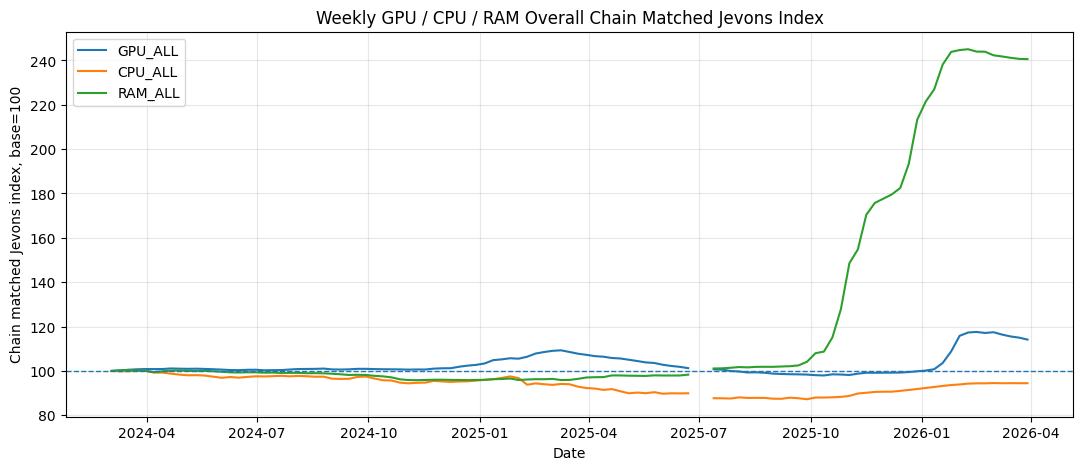

[saved plot] output_pic\Weekly_GPU_Chip-based_Performance_Group_Chain_Matched_Jevons_Index.png


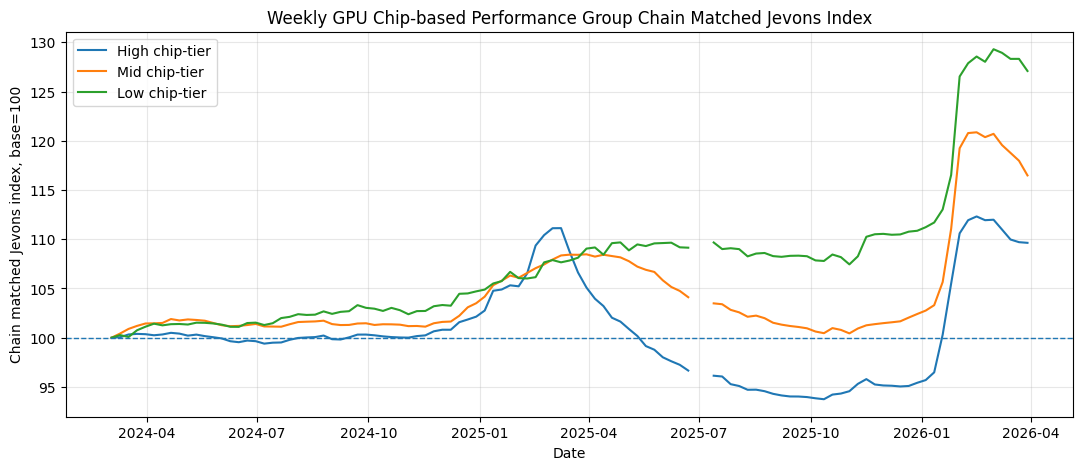

[saved plot] output_pic\Weekly_GPU_VRAM_Proxy_Chain_Matched_Jevons_Index,_Auxiliary.png


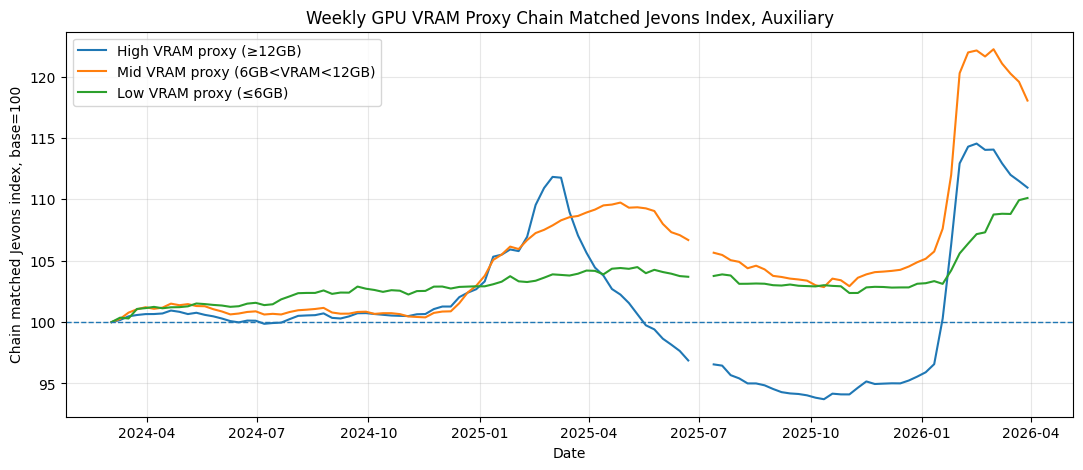

In [9]:
CHIP_LABEL = {
    "low": "Low chip-tier",
    "mid": "Mid chip-tier",
    "high": "High chip-tier",
}

VRAM_LABEL = {
    "low": "Low VRAM proxy (≤6GB)",
    "mid": "Mid VRAM proxy (6GB<VRAM<12GB)",
    "high": "High VRAM proxy (≥12GB)",
}


def plot_idx(index_df, title, value_col="index_valid", label_map=None, order=None):
    plt.figure(figsize=(13, 5))
    groups = order if order is not None else list(index_df["group"].dropna().unique())

    for group in groups:
        sub = index_df[index_df["group"] == group].sort_values("date")
        if len(sub):
            label = label_map.get(group, group) if label_map else group
            plt.plot(sub["date"], sub[value_col], label=label)

    plt.axhline(100, linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Chain matched Jevons index, base=100")
    plt.legend()
    plt.grid(True, alpha=0.3)
    save_plot(); plt.show()


plot_idx(idx_all, "Weekly GPU / CPU / RAM Overall Chain Matched Jevons Index")
plot_idx(idx_chip, "Weekly GPU Chip-based Performance Group Chain Matched Jevons Index", label_map=CHIP_LABEL, order=["high", "mid", "low"])
plot_idx(idx_vram, "Weekly GPU VRAM Proxy Chain Matched Jevons Index, Auxiliary", label_map=VRAM_LABEL, order=["high", "mid", "low"])

In [10]:
def idx_summary(index_df, eps=1e-4, jump_threshold=0.08):
    temp = index_df.copy()
    temp["is_valid_return"] = temp["ret_ok"] & temp["ret_w"].notna()
    temp["is_flat"] = temp["is_valid_return"] & (temp["ret_w"].abs() <= eps)
    temp["is_big_jump"] = temp["is_valid_return"] & (temp["ret_w"].abs() >= jump_threshold)
    temp["is_trimmed"] = temp["n_adj_trim"].fillna(0) > 0

    return (
        temp.groupby("group")
            .agg(
                total_rows=("date", "size"),
                valid_return_weeks=("is_valid_return", "sum"),
                invalid_return_weeks=("ret_ok", lambda x: (~x).sum()),
                bridge_weeks=("bridge", "sum"),
                flat_weeks=("is_flat", "sum"),
                big_jump_weeks=("is_big_jump", "sum"),
                trimmed_weeks=("is_trimmed", "sum"),
                median_n_adj=("n_adj", "median"),
                max_abs_ret_w=("ret_w", lambda x: np.nanmax(np.abs(x)) if x.notna().any() else np.nan),
            )
            .reset_index()
    )


def top_moves(index_df, group=None, top=10, value_col="ret_w"):
    temp = index_df.dropna(subset=[value_col]).copy()
    if group is not None:
        temp = temp[temp["group"] == group].copy()
    temp[f"abs_{value_col}"] = temp[value_col].abs()
    return temp.sort_values(f"abs_{value_col}", ascending=False).head(top)


def week_moves(df, date_cols, group_col, group_value, target_week, idx_df=None, top=20):
    sub = df[df[group_col] == group_value].copy()
    X_weekly, weekly_dates = weekly_mat(sub, date_cols, agg=WEEKLY_AGG)

    target_week = pd.to_datetime(target_week).strftime("%Y-%m-%d")
    j = weekly_dates.index(target_week)

    if idx_df is not None:
        row = idx_df[(idx_df["group"] == str(group_value)) & (pd.to_datetime(idx_df["date"]) == pd.to_datetime(target_week))]
        if len(row) and pd.notna(row["from_date"].iloc[0]):
            prev_week = pd.to_datetime(row["from_date"].iloc[0]).strftime("%Y-%m-%d")
        else:
            prev_week = weekly_dates[j - 1]
    else:
        prev_week = weekly_dates[j - 1]

    step_n = max(1, weekly_dates.index(target_week) - weekly_dates.index(prev_week))
    logW = log_price(X_weekly[[prev_week, target_week]])
    r = (logW[target_week] - logW[prev_week]).dropna()
    meta_cols = ["Id", "Name", "vram_gb", "gpu_chip_clean", "chip_perf_group", "h2_perf_group"]

    out = sub.loc[r.index, meta_cols].copy()
    out["prev_week"] = prev_week
    out["target_week"] = target_week
    out["step_n"] = step_n
    out["price_prev"] = X_weekly.loc[r.index, prev_week]
    out["price_target"] = X_weekly.loc[r.index, target_week]
    out["log_return"] = r
    out["ret_lvl"] = r / step_n
    out["ret_w"] = r if step_n == 1 else np.nan
    out["price_ratio"] = np.exp(r)
    out["abs_ret_lvl"] = out["ret_lvl"].abs()
    return out.sort_values("abs_ret_lvl", ascending=False).head(top)


idx_behavior = idx_summary(idx_chip)
print("H2 chip return behavior")
display(idx_behavior)

print("overall largest observed weekly moves")
display(top_moves(idx_all, top=10))
print("H2 chip largest observed weekly moves")
display(top_moves(idx_chip, top=15))

print("H2 chip largest bridge-level moves")
display(top_moves(idx_chip, top=10, value_col="ret_lvl"))

top_high = top_moves(idx_chip, group="high", top=1)
if len(top_high):
    top_high_week = top_high["date"].iloc[0]
    print("high chip group largest observed move week:", top_high_week)
    display(week_moves(gpu_dedup, g_dates, "chip_perf_group", "high", top_high_week, idx_df=idx_chip, top=20))

H2 chip return behavior


,group,total_rows,valid_return_weeks,invalid_return_weeks,bridge_weeks,flat_weeks,big_jump_weeks,trimmed_weeks,median_n_adj,max_abs_ret_w
0,high,110,105,5,1,4,0,105,269.0,0.050568
1,low,110,105,5,1,2,1,105,43.0,0.082301
2,mid,110,105,5,1,1,0,105,316.0,0.071036


overall largest observed weekly moves


,date,group,from_date,index_ffill,index_valid,log_return,ret_lvl,ret_w,n_matched,n_used,n_trim,n_adj,n_adj_used,n_adj_trim,step_n,interval_days,bridge,valid_step,ret_ok,abs_ret_w
307,2025-11-02,RAM_ALL,2025-10-26,148.571046,148.571046,0.150000,0.150000,0.150000,801,703,98,801,703,98,1,7.0,False,True,True,0.150000
306,2025-10-26,RAM_ALL,2025-10-19,127.876260,127.876260,0.104900,0.104900,0.104900,963,856,107,963,856,107,1,7.0,False,True,True,0.104900
315,2025-12-28,RAM_ALL,2025-12-21,213.270634,213.270634,0.098235,0.098235,0.098235,823,730,93,823,730,93,1,7.0,False,True,True,0.098235
309,2025-11-16,RAM_ALL,2025-11-09,170.457944,170.457944,0.096437,0.096437,0.096437,867,774,93,867,774,93,1,7.0,False,True,True,0.096437
100,2026-02-01,GPU_ALL,2026-01-25,115.841657,115.841657,0.062805,0.062805,0.062805,654,580,74,654,580,74,1,7.0,False,True,True,0.062805
314,2025-12-21,RAM_ALL,2025-12-14,193.316132,193.316132,0.057649,0.057649,0.057649,878,778,100,878,778,100,1,7.0,False,True,True,0.057649
305,2025-10-19,RAM_ALL,2025-10-12,115.141646,115.141646,0.057411,0.057411,0.057411,1088,972,116,1088,972,116,1,7.0,False,True,True,0.057411
99,2026-01-25,GPU_ALL,2026-01-18,108.789982,108.789982,0.049184,0.049184,0.049184,680,607,73,680,607,73,1,7.0,False,True,True,0.049184
318,2026-01-18,RAM_ALL,2026-01-11,238.102006,238.102006,0.047952,0.047952,0.047952,826,739,87,826,739,87,1,7.0,False,True,True,0.047952
308,2025-11-09,RAM_ALL,2025-11-02,154.787213,154.787213,0.040988,0.040988,0.040988,897,802,95,897,802,95,1,7.0,False,True,True,0.040988


H2 chip largest observed weekly moves


,date,group,from_date,index_ffill,index_valid,log_return,ret_lvl,ret_w,n_matched,n_used,n_trim,n_adj,n_adj_used,n_adj_trim,step_n,interval_days,bridge,valid_step,ret_ok,abs_ret_w
210,2026-02-01,low,2026-01-25,126.528366,126.528366,0.082301,0.082301,0.082301,43,37,6,43,37,6,1,7.0,False,True,True,0.082301
320,2026-02-01,mid,2026-01-25,119.242356,119.242356,0.071036,0.071036,0.071036,366,325,41,366,325,41,1,7.0,False,True,True,0.071036
99,2026-01-25,high,2026-01-18,105.506155,105.506155,0.050568,0.050568,0.050568,243,216,27,243,216,27,1,7.0,False,True,True,0.050568
319,2026-01-25,mid,2026-01-18,111.065693,111.065693,0.049967,0.049967,0.049967,399,355,44,399,355,44,1,7.0,False,True,True,0.049967
100,2026-02-01,high,2026-01-25,110.598313,110.598313,0.047136,0.047136,0.047136,245,216,29,245,216,29,1,7.0,False,True,True,0.047136
98,2026-01-18,high,2026-01-11,100.303599,100.303599,0.038873,0.038873,0.038873,248,222,26,248,222,26,1,7.0,False,True,True,0.038873
209,2026-01-25,low,2026-01-18,116.532005,116.532005,0.030558,0.030558,0.030558,38,34,4,38,34,4,1,7.0,False,True,True,0.030558
50,2025-02-16,high,2025-02-09,109.357988,109.357988,0.026299,0.026299,0.026299,270,239,31,270,239,31,1,7.0,False,True,True,0.026299
318,2026-01-18,mid,2026-01-11,105.652466,105.652466,0.022493,0.022493,0.022493,401,360,41,401,360,41,1,7.0,False,True,True,0.022493
54,2025-03-16,high,2025-03-09,108.758654,108.758654,-0.021547,-0.021547,-0.021547,180,162,18,180,162,18,1,7.0,False,True,True,0.021547


H2 chip largest bridge-level moves


,date,group,from_date,index_ffill,index_valid,log_return,ret_lvl,ret_w,n_matched,n_used,n_trim,n_adj,n_adj_used,n_adj_trim,step_n,interval_days,bridge,valid_step,ret_ok,abs_ret_lvl
210,2026-02-01,low,2026-01-25,126.528366,126.528366,0.082301,0.082301,0.082301,43,37,6,43,37,6,1,7.0,False,True,True,0.082301
320,2026-02-01,mid,2026-01-25,119.242356,119.242356,0.071036,0.071036,0.071036,366,325,41,366,325,41,1,7.0,False,True,True,0.071036
99,2026-01-25,high,2026-01-18,105.506155,105.506155,0.050568,0.050568,0.050568,243,216,27,243,216,27,1,7.0,False,True,True,0.050568
319,2026-01-25,mid,2026-01-18,111.065693,111.065693,0.049967,0.049967,0.049967,399,355,44,399,355,44,1,7.0,False,True,True,0.049967
100,2026-02-01,high,2026-01-25,110.598313,110.598313,0.047136,0.047136,0.047136,245,216,29,245,216,29,1,7.0,False,True,True,0.047136
98,2026-01-18,high,2026-01-11,100.303599,100.303599,0.038873,0.038873,0.038873,248,222,26,248,222,26,1,7.0,False,True,True,0.038873
209,2026-01-25,low,2026-01-18,116.532005,116.532005,0.030558,0.030558,0.030558,38,34,4,38,34,4,1,7.0,False,True,True,0.030558
50,2025-02-16,high,2025-02-09,109.357988,109.357988,0.026299,0.026299,0.026299,270,239,31,270,239,31,1,7.0,False,True,True,0.026299
318,2026-01-18,mid,2026-01-11,105.652466,105.652466,0.022493,0.022493,0.022493,401,360,41,401,360,41,1,7.0,False,True,True,0.022493
54,2025-03-16,high,2025-03-09,108.758654,108.758654,-0.021547,-0.021547,-0.021547,180,162,18,180,162,18,1,7.0,False,True,True,0.021547


high chip group largest observed move week: 2026-01-25 00:00:00


,Id,Name,vram_gb,gpu_chip_clean,chip_perf_group,h2_perf_group,prev_week,target_week,step_n,price_prev,price_target,log_return,ret_lvl,ret_w,price_ratio,abs_ret_lvl
1314,76329767,MSI 지포스 RTX 5080 게이밍 트리오 OC 화이트 D7 16GB 트라이프로져4,16.0,RTX 5080,high,high,2026-01-18,2026-01-25,1,2364730.0,4400000.0,0.620941,0.620941,0.620941,1.860678,0.620941
1285,75376346,MANLI 지포스 RTX 5090 Gallardo OC D7 32GB 대원씨티에스,32.0,RTX 5090,high,high,2026-01-18,2026-01-25,1,4655030.0,7900000.0,0.528914,0.528914,0.528914,1.697089,0.528914
1334,76464395,ZOTAC GAMING 지포스 RTX 5070 Ti AMP Extreme Infin...,16.0,RTX 5070 TI,high,high,2026-01-18,2026-01-25,1,1787500.0,2749870.0,0.430736,0.430736,0.430736,1.538389,0.430736
1252,75184241,GIGABYTE 지포스 RTX 5090 WINDFORCE OC D7 32GB 피씨디렉트,32.0,RTX 5090,high,high,2026-01-18,2026-01-25,1,5998990.0,8749500.0,0.377405,0.377405,0.377405,1.458496,0.377405
1250,75184235,GIGABYTE AORUS 지포스 RTX 5090 XTREME 워터포스 D7 32G...,32.0,RTX 5090,high,high,2026-01-18,2026-01-25,1,6198990.0,8749500.0,0.344610,0.344610,0.344610,1.411440,0.344610
1284,75376205,MANLI 지포스 RTX 5080 Stellar OC D7 16GB 대원씨티에스,16.0,RTX 5080,high,high,2026-01-18,2026-01-25,1,2214810.0,3054400.0,0.321417,0.321417,0.321417,1.379080,0.321417
1310,75991625,GAINWARD 지포스 RTX 5090 팬텀 D7 32GB,32.0,RTX 5090,high,high,2026-01-18,2026-01-25,1,5100000.0,6990000.0,0.315240,0.315240,0.315240,1.370588,0.315240
1249,75184232,GIGABYTE AORUS 지포스 RTX 5090 XTREME 워터블럭 D7 32G...,32.0,RTX 5090,high,high,2026-01-18,2026-01-25,1,6543390.0,8749500.0,0.290541,0.290541,0.290541,1.337151,0.290541
1364,76551050,GIGABYTE 지포스 RTX 5070 Ti EAGLE OC ICE SFF D7 1...,16.0,RTX 5070 TI,high,high,2026-01-18,2026-01-25,1,1379580.0,1784190.0,0.257185,0.257185,0.257185,1.293285,0.257185
1466,77791169,MSI 지포스 RTX 5080 벤투스 3X OC 화이트 D7 16GB,16.0,RTX 5080,high,high,2026-01-18,2026-01-25,1,1859000.0,2399000.0,0.255013,0.255013,0.255013,1.290479,0.255013


[saved plot] output_pic\H2_High_chip-tier_weekly_median_vs_last.png


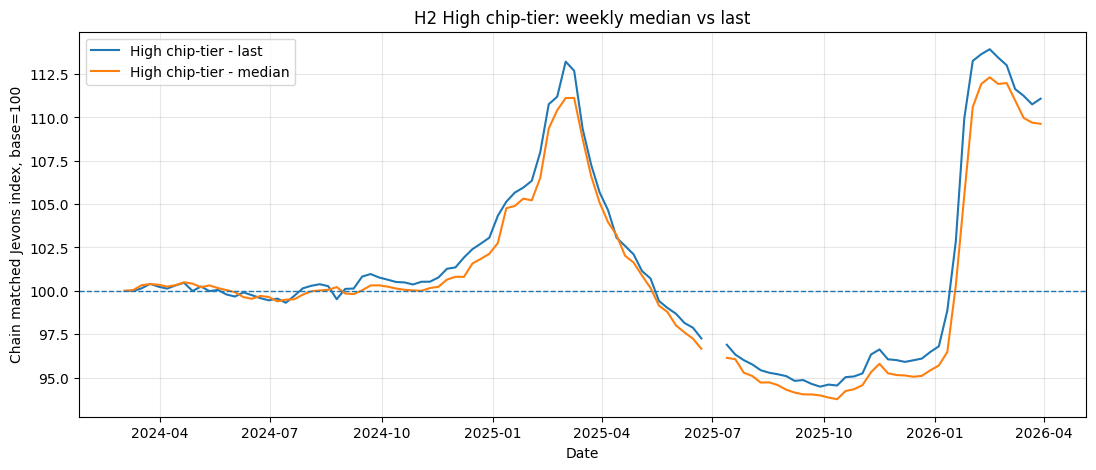

[saved plot] output_pic\H2_Mid_chip-tier_weekly_median_vs_last.png


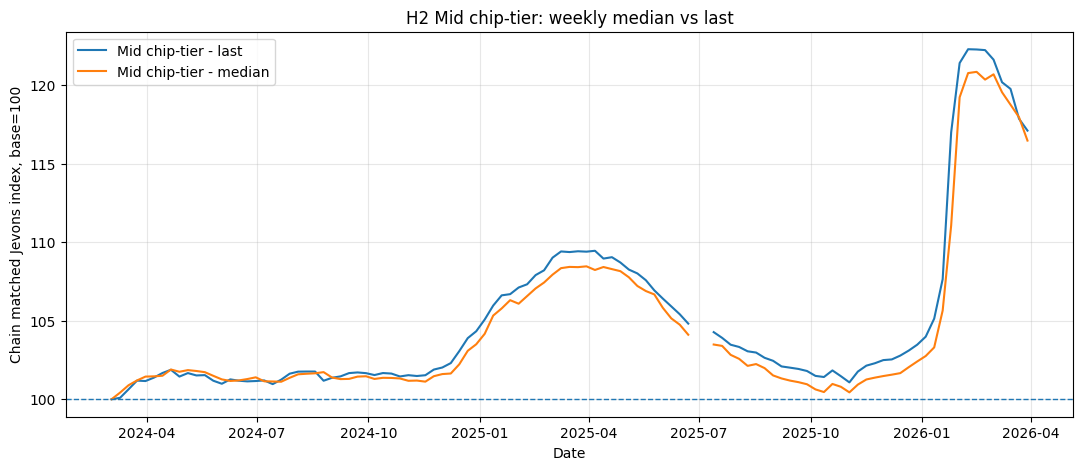

[saved plot] output_pic\H2_Low_chip-tier_weekly_median_vs_last.png


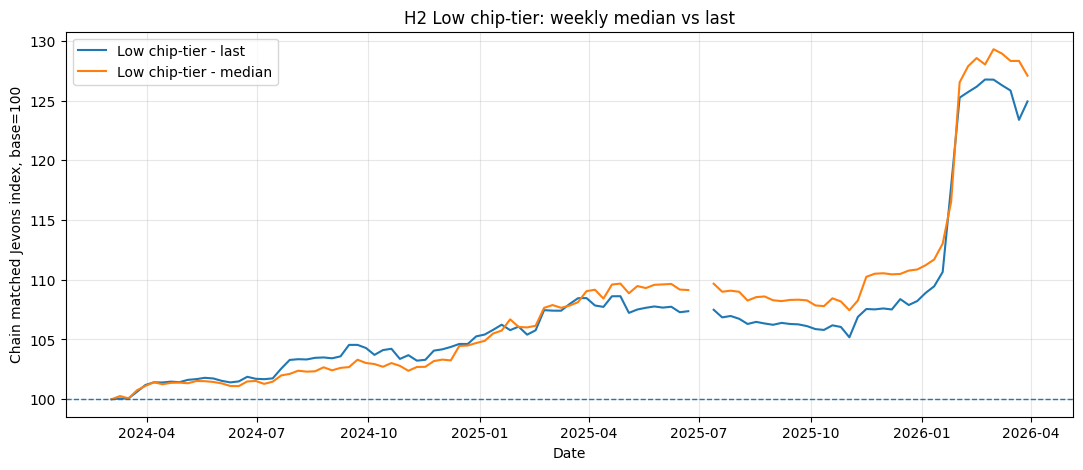

,group,weekly_agg,date,index_valid
438,high,last,2026-03-29,111.083226
108,high,median,2026-03-29,109.634276
548,low,last,2026-03-29,124.928586
218,low,median,2026-03-29,127.089296
658,mid,last,2026-03-29,117.118011
328,mid,median,2026-03-29,116.482401


[saved plot] output_pic\Chain_drift_check_High_chip-tier.png


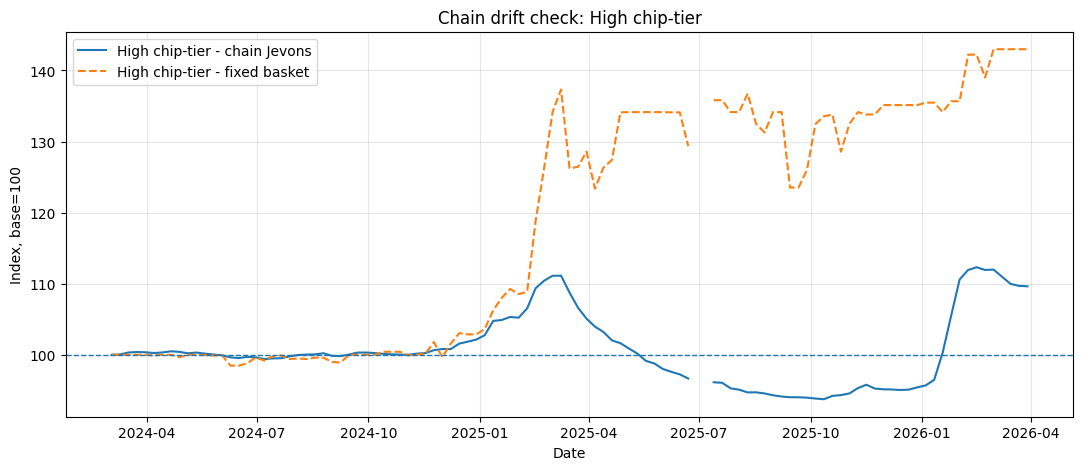

[saved plot] output_pic\Chain_drift_check_Mid_chip-tier.png


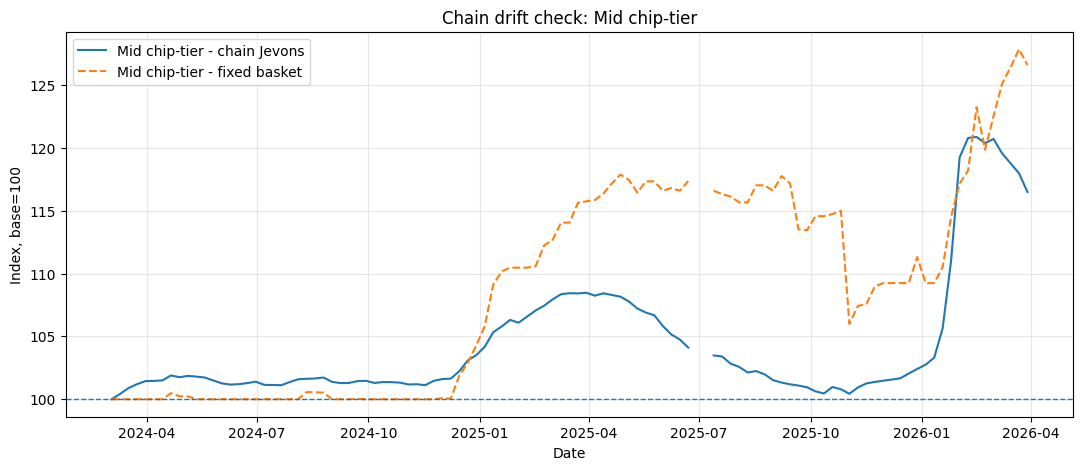

[saved plot] output_pic\Chain_drift_check_Low_chip-tier.png


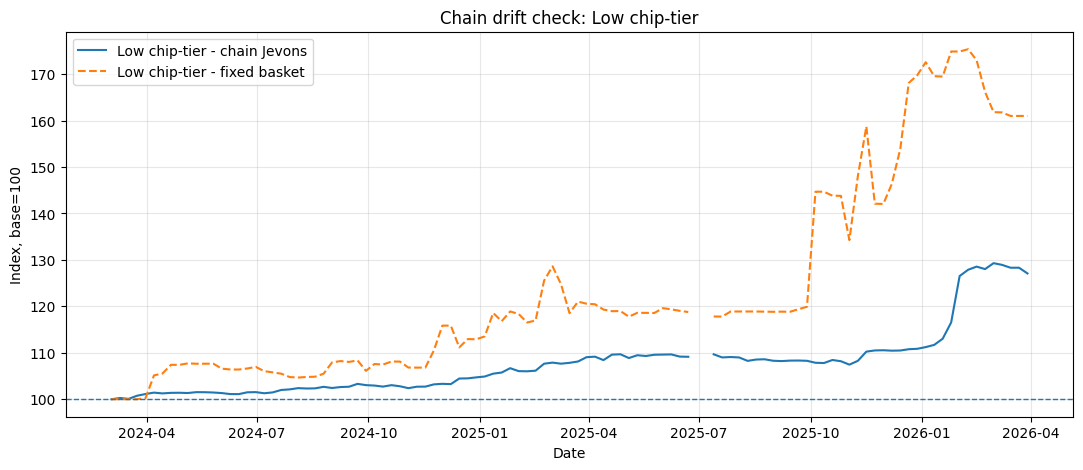

fixed basket product count


,group,basket_n
0,high,34
1,low,8
2,mid,84


In [11]:
agg_check = pd.concat(
    [
        build_group_idx(
            gpu_dedup,
            g_dates,
            group_col="chip_perf_group",
            min_matched=MIN_GRP,
            keep_groups=["low", "mid", "high"],
            agg=agg_name,
        ).assign(weekly_agg=agg_name)
        for agg_name in AGG_CHECK
    ],
    ignore_index=True,
)


def plot_agg(index_df, group):
    plt.figure(figsize=(13, 5))
    for agg_name, sub in index_df[index_df["group"] == group].groupby("weekly_agg"):
        sub = sub.sort_values("date")
        plt.plot(sub["date"], sub["index_valid"], label=f"{CHIP_LABEL.get(group, group)} - {agg_name}")

    plt.axhline(100, linestyle="--", linewidth=1)
    plt.title(f"H2 {CHIP_LABEL.get(group, group)}: weekly median vs last")
    plt.xlabel("Date")
    plt.ylabel("Chain matched Jevons index, base=100")
    plt.legend()
    plt.grid(True, alpha=0.3)
    save_plot(); plt.show()


for group in ["high", "mid", "low"]:
    plot_agg(agg_check, group)

agg_last = (
    agg_check.dropna(subset=["index_valid"])
    .sort_values("date")
    .groupby(["group", "weekly_agg"])
    .tail(1)
    [["group", "weekly_agg", "date", "index_valid"]]
    .sort_values(["group", "weekly_agg"])
)

display(agg_last)


def fixed_idx(df, date_cols, group_name="ALL", min_coverage=0.70, agg=WEEKLY_AGG, base=BASE_INDEX):
    X_weekly, weekly_dates = weekly_mat(df, date_cols, agg=agg)
    basket = X_weekly.loc[X_weekly.notna().mean(axis=1) >= min_coverage].copy()

    first_valid = basket.apply(lambda r: r.dropna().iloc[0] if r.notna().any() else np.nan, axis=1)
    idx = basket.div(first_valid, axis=0).mul(base).median(axis=0, skipna=True)

    return pd.DataFrame({
        "date": pd.to_datetime(weekly_dates),
        "group": group_name,
        "fixed_basket_index": idx.values,
        "basket_n": len(basket),
    })


def build_fixed_idx(df, date_cols, group_col, keep_groups, min_coverage=0.70, agg=WEEKLY_AGG):
    parts = []
    for group, sub in df.groupby(group_col, dropna=False):
        group = "unknown" if pd.isna(group) else str(group)
        if group in keep_groups:
            parts.append(fixed_idx(sub, date_cols, group, min_coverage, agg, BASE_INDEX))
    return pd.concat(parts, ignore_index=True)


def plot_fixed(chain_df, fixed_df, group):
    plt.figure(figsize=(13, 5))
    chain = chain_df[chain_df["group"] == group].sort_values("date")
    fixed = fixed_df[fixed_df["group"] == group].sort_values("date")

    plt.plot(chain["date"], chain["index_valid"], label=f"{CHIP_LABEL.get(group, group)} - chain Jevons")
    plt.plot(fixed["date"], fixed["fixed_basket_index"], label=f"{CHIP_LABEL.get(group, group)} - fixed basket", linestyle="--")
    plt.axhline(100, linestyle="--", linewidth=1)
    plt.title(f"Chain drift check: {CHIP_LABEL.get(group, group)}")
    plt.xlabel("Date")
    plt.ylabel("Index, base=100")
    plt.legend()
    plt.grid(True, alpha=0.3)
    save_plot(); plt.show()


idx_fixed = build_fixed_idx(
    gpu_dedup,
    g_dates,
    group_col="chip_perf_group",
    keep_groups=["low", "mid", "high"],
    min_coverage=0.70,
    agg=WEEKLY_AGG,
)

for group in ["high", "mid", "low"]:
    plot_fixed(idx_chip, idx_fixed, group)

print("fixed basket product count")
display(idx_fixed.groupby("group")["basket_n"].max().reset_index())

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>최종 변수 셋업 및 가설검정용 데이터 저장</mark></b></span><br><br>

<b>[시각화용 변수]</b><br>
• 누적된 가격 수준의 흐름을 보여줄 때는 <b>index_valid</b>를 사용<br>
• index_valid는 matched product 수가 부족한 주를 NaN으로 남기므로 그래프가 끊길 수 있음<br>
• 단절 이후 bridge가 성공한 주에는 마지막 유효 주부터 현재 주까지의 누적 변화가 지수에 반영됨<br><br>

<b>[통계분석용 변수]</b><br>
• 상관분석, 회귀분석, ANOVA, interaction regression에는 가격 수준이 아니라 <b>log return</b>을 사용<br>
• <b>ret_w</b>는 인접 주 t-1 → t에서 min_matched를 만족한 경우만 저장한 검정용 주간 로그수익률<br>
• <b>ret_lvl</b>은 지수 레벨을 이어가기 위한 주간 환산 수익률이며, bridge=True인 행에서는 평활화된 값이므로 기본 검정에는 사용하지 않음<br>
• <b>log_return</b>은 지수 갱신에 사용된 anchor-current 구간 누적 로그수익률<br>
• 따라서 BTC 주간 수익률과 맞춰 분석할 때는 기본적으로 <b>ret_w</b>를 사용하고, bridge 여부는 진단표에서만 확인<br><br>

<b>[가설별 데이터 매핑]</b><br>
• H1: <b>GPU_ALL index_valid</b>는 그림 설명용, <b>GPU_ALL ret_w</b>는 BTC 주간 수익률과의 검정용<br>
• H2: <b>GPU chip_perf_group별 ret_w</b>를 본분석으로 사용하고, 제품 단위 product-week return panel을 활용해 성능군별 민감도 차이를 검정<br>
• H2 보조분석: <b>h2_perf_group</b> 기반 VRAM proxy 지수를 함께 저장하여 결과의 강건성을 확인<br>
• H3: <b>GPU_ALL, CPU_ALL, RAM_ALL</b>의 ret_w를 비교하여 BTC 민감도 차이를 검정<br><br>

<b>[동일가중 지수의 한계]</b><br>
• 본 데이터에는 판매량이 없으므로 시장점유율 가중 지수는 만들지 않음<br>
• 대신 각 제품의 상대적 가격 변화율을 같은 비중으로 반영하는 Jevons Index로 성능군별 전반적 가격 흐름을 추적<br>
• 발표에서는 이 점을 한계로 인정하되, 특정 인기 모델 하나에 과도하게 끌리지 않는다는 장점도 함께 설명<br><br>

<span style="color: #e53e3e; font-size: 18px;"><b>핵심: index_valid는 그림 설명용, ret_w는 bridge smoothing이 빠진 기본 검정용, ret_lvl은 지수 레벨 복구용이다.</b></span>

<br>
<b>[검정용 변수 주의]</b><br>
저장되는 ret_w는 인접 주 기준으로 충분한 매칭이 존재한 주만 남긴 관측 수익률이다. bridge로 복구된 ret_lvl은 지수 레벨 점검 및 시각화 보조용이며, BTC 민감도 회귀나 상관분석에는 사용하지 않는다. 또한 weekly median은 최소 3일 이상 관측된 제품-주만 인정하고, 로그수익률 평균은 명백한 오류성 변동을 제거한 뒤 표본 수가 충분할 때만 5% 절사평균을 적용한다. 제품 단위 panel은 최종 회귀 입력이므로 long-form으로 저장하되, 중간 진단 함수에서는 불필요한 전체 melt를 피했다.<br><br>

<b>[환율 처리 원칙]</b><br>
국내 하드웨어 가격은 KRW 기준이므로, BTC를 USD 기준으로 그대로 붙이면 원/달러 환율 변동이 함께 섞일 수 있다. 따라서 기본 검정에서는 BTC-USD가 아니라 <b>BTC-KRW 주간 로그수익률</b>을 사용한다. 원/달러 환율 자체의 영향은 별도 통제변수로 저장하여, 회귀분석에서 필요하면 fx_ret을 추가한다.<br><br>
</div>

In [12]:
idx_all_w = idx_all.pivot(index="date", columns="group", values="index_valid")
ret_all_w = idx_all.pivot(index="date", columns="group", values="ret_w")
ret_all_lvl_w = idx_all.pivot(index="date", columns="group", values="ret_lvl")
ret_all_int_w = idx_all.pivot(index="date", columns="group", values="log_return")

idx_chip_w = idx_chip.pivot(index="date", columns="group", values="index_valid")
ret_chip_w = idx_chip.pivot(index="date", columns="group", values="ret_w")
ret_chip_lvl_w = idx_chip.pivot(index="date", columns="group", values="ret_lvl")
ret_chip_int_w = idx_chip.pivot(index="date", columns="group", values="log_return")

idx_vram_w = idx_vram.pivot(index="date", columns="group", values="index_valid")
ret_vram_w = idx_vram.pivot(index="date", columns="group", values="ret_w")
ret_vram_lvl_w = idx_vram.pivot(index="date", columns="group", values="ret_lvl")
ret_vram_int_w = idx_vram.pivot(index="date", columns="group", values="log_return")

idx_chip_w_copy = idx_chip_w.copy()
ret_chip_w_copy = ret_chip_w.copy()

print("idx_all_w")
display(idx_all_w.head())
print("ret_all_w, observed adjacent weekly return for tests")
display(ret_all_w.head())
print("ret_all_lvl_w, level-link return for index bridge check")
display(ret_all_lvl_w.head())
print("idx_chip_w, chip main")
display(idx_chip_w.head())
print("idx_vram_w, VRAM proxy")
display(idx_vram_w.head())


def make_panel(df, date_cols, freq=WEEKLY_FREQ, agg=WEEKLY_AGG):
    df0 = df.reset_index(drop=True).copy()
    X_weekly, weekly_cols = weekly_mat(df0, date_cols, freq=freq, agg=agg)
    R = log_price(X_weekly).diff(axis=1)

    vals = R.to_numpy()
    row_i, col_i = np.where(np.isfinite(vals))
    panel = pd.DataFrame({
        "row_id": row_i.astype(int),
        "date": pd.to_datetime(np.array(R.columns)[col_i]),
        "gpu_log_return": vals[row_i, col_i],
    })

    meta_cols = ["Id", "Name", "vram_gb", "gpu_chip_clean", "chip_perf_group", "h2_perf_group"]
    meta = df0[meta_cols].copy()
    meta["row_id"] = np.arange(len(meta))

    return panel.merge(meta, on="row_id", how="left")


panel_gpu = make_panel(gpu_dedup, g_dates)

print("product-week return panel")
display(panel_gpu.head())

print("product-week return count by chip group")
display(
    panel_gpu.groupby("chip_perf_group")
    .agg(
        obs_n=("gpu_log_return", "count"),
        product_n=("row_id", "nunique"),
        mean_return=("gpu_log_return", "mean"),
        std_return=("gpu_log_return", "std"),
    )
    .reset_index()
)

idx_all_w


group,CPU_ALL,GPU_ALL,RAM_ALL
date,,,
2024-03-03,100.000000,100.000000,100.000000
2024-03-10,99.852310,100.219113,100.290052
2024-03-17,99.903003,100.529455,100.437865
2024-03-24,99.970296,100.735714,100.135426
2024-03-31,100.074729,100.845916,99.984497


ret_all_w, observed adjacent weekly return for tests


group,CPU_ALL,GPU_ALL,RAM_ALL
date,,,
2024-03-03,NaN,NaN,NaN
2024-03-10,-0.001478,0.002189,0.002896
2024-03-17,0.000508,0.003092,0.001473
2024-03-24,0.000673,0.002050,-0.003016
2024-03-31,0.001044,0.001093,-0.001508


ret_all_lvl_w, level-link return for index bridge check


...

group,high,low,mid
date,,,
2024-03-03,100.000000,100.000000,100.000000
2024-03-10,100.166202,100.358714,100.257885
2024-03-17,100.466184,100.294843,100.769214
2024-03-24,100.576636,101.070620,101.041990
2024-03-31,100.649900,101.136698,101.209525


product-week return panel


,row_id,date,gpu_log_return,Id,Name,vram_gb,gpu_chip_clean,chip_perf_group,h2_perf_group
0,1,2025-01-19,0.00000,6565469,갤럭시 GALAX 지포스 RTX 2080 Ti Hall Of Fame D6 11GB,11.0,RTX 2080 TI,high,mid
1,1,2025-01-26,0.00000,6565469,갤럭시 GALAX 지포스 RTX 2080 Ti Hall Of Fame D6 11GB,11.0,RTX 2080 TI,high,mid
2,1,2025-02-02,0.00000,6565469,갤럭시 GALAX 지포스 RTX 2080 Ti Hall Of Fame D6 11GB,11.0,RTX 2080 TI,high,mid
3,1,2025-02-09,0.00000,6565469,갤럭시 GALAX 지포스 RTX 2080 Ti Hall Of Fame D6 11GB,11.0,RTX 2080 TI,high,mid
4,1,2025-02-16,-0.04652,6565469,갤럭시 GALAX 지포스 RTX 2080 Ti Hall Of Fame D6 11GB,11.0,RTX 2080 TI,high,mid


product-week return count by chip group


,chip_perf_group,obs_n,product_n,mean_return,std_return
0,high,31857,857,0.002778,0.062445
1,low,4587,143,0.005152,0.088097
2,mid,35513,893,0.003490,0.065043


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>절사평균 민감도 점검: 5% trim 제거 지수 추가 산출</mark></b></span><br><br>

<b>[왜 추가하는가]</b><br>
기본 지수는 명백한 크롤링 오류를 줄이기 위해 주간 로그수익률의 상하위 5%를 절사한다. 이 처리는 이상치 방어에는 유리하지만, 암호화폐 급등락 시기에 실제로 발생한 하드웨어 가격 충격까지 일부 평활화할 수 있다. 따라서 <b>하드 오류 필터(np.log(1.8))는 유지하되, 분위수 절사(q=0)는 제거한 no-trim 지수</b>를 별도로 만든다.<br><br>

<b>[해석 원칙]</b><br>
main 지수와 no-trim 지수의 수익률 상관이 높고 이후 Hypo 1/Hypo 2 결론이 유지되면, 5% 절사평균이 결론을 인위적으로 만든 것이 아니라고 볼 수 있다. 반대로 no-trim에서만 결론이 크게 바뀌면, 결과가 극단 가격변동 처리 방식에 민감하다는 한계로 보고한다.<br><br>

<span style="color: #e53e3e; font-size: 18px;"><b>핵심: main output은 그대로 유지하고, no-trim output은 robustness 전용으로 추가 저장한다.</b></span>
</div>

main vs no-trim return robustness


,block,group,n,corr_main_notrim,mean_abs_diff,max_abs_diff,main_std,notrim_std
0,all,GPU_ALL,105,0.98238,0.00216,0.00929,0.00920,0.01102
1,all,CPU_ALL,105,0.92477,0.00315,0.01907,0.00556,0.00882
2,all,RAM_ALL,105,0.99535,0.00278,0.01153,0.02450,0.02716
3,chip,high,105,0.98113,0.00247,0.01255,0.00991,0.01249
4,chip,mid,105,0.97936,0.00214,0.00792,0.00950,0.01098
5,chip,low,105,0.86906,0.00500,0.02273,0.00955,0.01257
6,vram,high,105,0.98381,0.00243,0.01276,0.01092,0.01327
7,vram,mid,105,0.96708,0.00225,0.00894,0.00899,0.01030
8,vram,low,105,0.77618,0.00404,0.02911,0.00316,0.00756


[saved plot] output_pic\Trim_sensitivity_GPU_overall_index.png


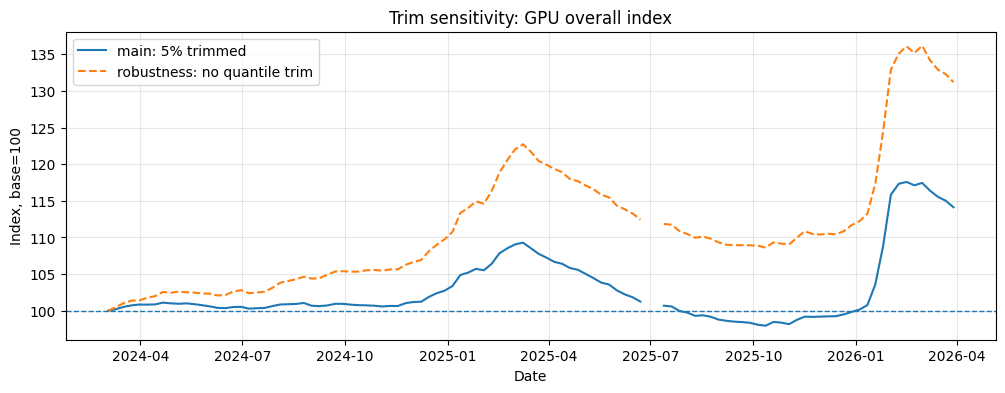

[saved plot] output_pic\Trim_sensitivity_chip_high_index.png


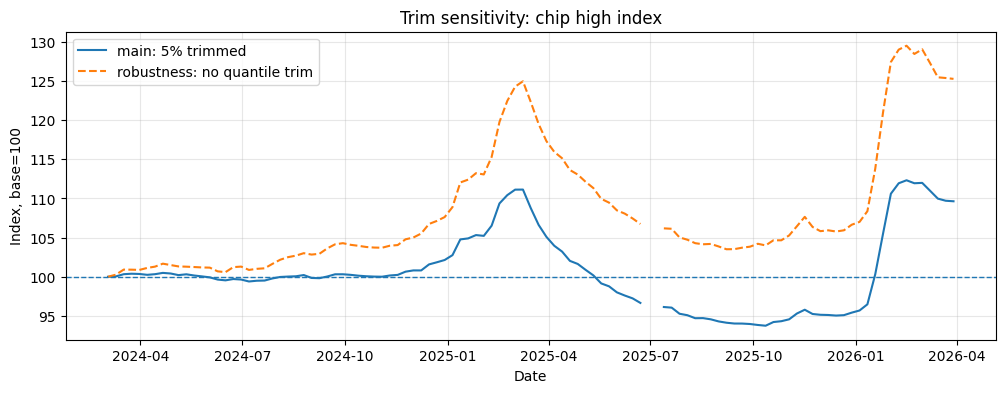

[saved plot] output_pic\Trim_sensitivity_chip_mid_index.png


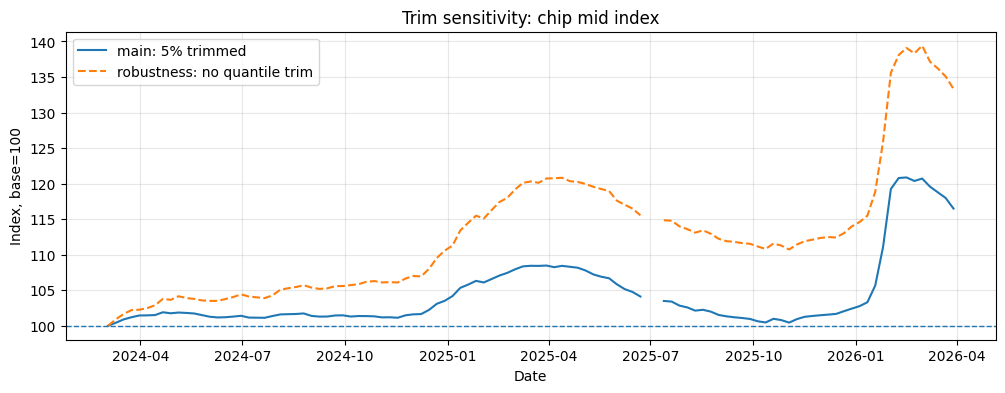

[saved plot] output_pic\Trim_sensitivity_chip_low_index.png


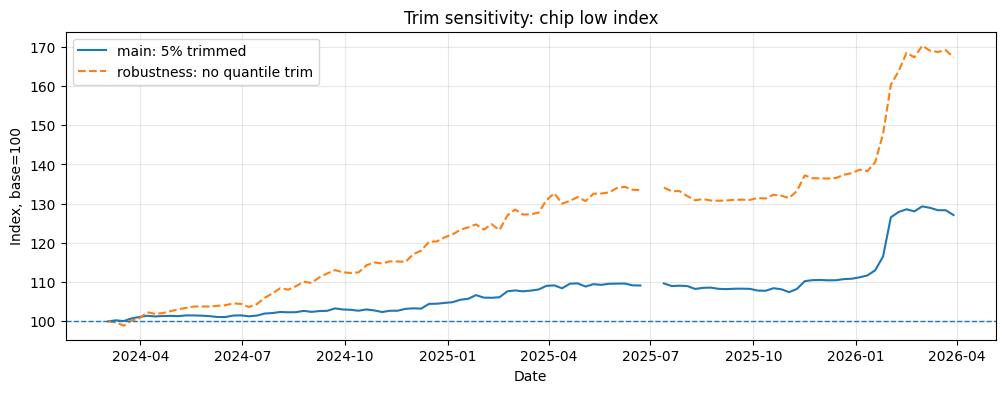

In [13]:
idx_gpu_notrim = build_idx(gpu_dedup, g_dates, "GPU_ALL", MIN_ALL, q=0.0)
idx_cpu_notrim = build_idx(cpu_dedup, c_dates, "CPU_ALL", MIN_ALL, q=0.0)
idx_ram_notrim = build_idx(ram_dedup, r_dates, "RAM_ALL", MIN_ALL, q=0.0)
idx_all_notrim = pd.concat([idx_gpu_notrim, idx_cpu_notrim, idx_ram_notrim], ignore_index=True)

idx_chip_notrim = build_group_idx(
    gpu_dedup,
    g_dates,
    group_col="chip_perf_group",
    min_matched=MIN_GRP,
    keep_groups=["low", "mid", "high"],
    q=0.0,
)

idx_vram_notrim = build_group_idx(
    gpu_dedup,
    g_dates,
    group_col="h2_perf_group",
    min_matched=MIN_GRP,
    keep_groups=["low", "mid", "high"],
    q=0.0,
)

idx_all_notrim_w = idx_all_notrim.pivot(index="date", columns="group", values="index_valid")
ret_all_notrim_w = idx_all_notrim.pivot(index="date", columns="group", values="ret_w")
idx_chip_notrim_w = idx_chip_notrim.pivot(index="date", columns="group", values="index_valid")
ret_chip_notrim_w = idx_chip_notrim.pivot(index="date", columns="group", values="ret_w")
idx_vram_notrim_w = idx_vram_notrim.pivot(index="date", columns="group", values="index_valid")
ret_vram_notrim_w = idx_vram_notrim.pivot(index="date", columns="group", values="ret_w")


def compare_trim(main_w, notrim_w, cols, block):
    rows = []
    for col in cols:
        temp = (
            main_w[[col]]
            .rename(columns={col: "main_ret"})
            .join(notrim_w[[col]].rename(columns={col: "notrim_ret"}), how="inner")
            .dropna()
        )
        if len(temp) == 0:
            continue
        diff = temp["notrim_ret"] - temp["main_ret"]
        rows.append({
            "block": block,
            "group": col,
            "n": len(temp),
            "corr_main_notrim": temp["main_ret"].corr(temp["notrim_ret"]),
            "mean_abs_diff": diff.abs().mean(),
            "max_abs_diff": diff.abs().max(),
            "main_std": temp["main_ret"].std(),
            "notrim_std": temp["notrim_ret"].std(),
        })
    return pd.DataFrame(rows)


trim_robust = pd.concat(
    [
        compare_trim(ret_all_w, ret_all_notrim_w, ["GPU_ALL", "CPU_ALL", "RAM_ALL"], "all"),
        compare_trim(ret_chip_w, ret_chip_notrim_w, ["high", "mid", "low"], "chip"),
        compare_trim(ret_vram_w, ret_vram_notrim_w, ["high", "mid", "low"], "vram"),
    ],
    ignore_index=True,
)

print("main vs no-trim return robustness")
display(trim_robust.round(5))


def plot_trim_compare(main_idx_w, notrim_idx_w, col, title):
    temp = (
        main_idx_w[[col]].rename(columns={col: "main"})
        .join(notrim_idx_w[[col]].rename(columns={col: "notrim"}), how="inner")
    )
    plt.figure(figsize=(12, 4))
    plt.plot(temp.index, temp["main"], label="main: 5% trimmed")
    plt.plot(temp.index, temp["notrim"], label="robustness: no quantile trim", linestyle="--")
    plt.axhline(100, linestyle="--", linewidth=1)
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel("Index, base=100")
    plt.legend()
    plt.grid(True, alpha=0.3)
    save_plot(); plt.show()


plot_trim_compare(idx_all_w, idx_all_notrim_w, "GPU_ALL", "Trim sensitivity: GPU overall index")
for group in ["high", "mid", "low"]:
    if group in idx_chip_w.columns:
        plot_trim_compare(idx_chip_w, idx_chip_notrim_w, group, f"Trim sensitivity: chip {group} index")

In [14]:
save_files = {
    "idx_all.csv": idx_all,
    "idx_chip.csv": idx_chip,
    "idx_vram.csv": idx_vram,
    "panel_gpu.csv": panel_gpu,
    "gpu_meta.csv": gpu_dedup,
    "cpu_meta.csv": cpu_dedup,
    "ram_meta.csv": ram_dedup,
    "diag_all.csv": diag_all,
    "diag_chip.csv": diag_chip,
    "diag_vram.csv": diag_vram,
    "diag_ret.csv": idx_behavior,
    "agg_check.csv": agg_last,
    "gap_sum.csv": gap_sum,
    "gap_week.csv": gap_week,
    "fixed_idx.csv": idx_fixed,
    "idx_all_notrim.csv": idx_all_notrim,
    "idx_chip_notrim.csv": idx_chip_notrim,
    "idx_vram_notrim.csv": idx_vram_notrim,
    "trim_robust.csv": trim_robust,
}

save_wide = {
    "idx_all_w.csv": idx_all_w,
    "ret_all_w.csv": ret_all_w,
    "ret_all_lvl_w.csv": ret_all_lvl_w,
    "ret_all_int_w.csv": ret_all_int_w,
    "idx_chip_w.csv": idx_chip_w,
    "ret_chip_w.csv": ret_chip_w,
    "ret_chip_lvl_w.csv": ret_chip_lvl_w,
    "ret_chip_int_w.csv": ret_chip_int_w,
    "idx_vram_w.csv": idx_vram_w,
    "ret_vram_w.csv": ret_vram_w,
    "ret_vram_lvl_w.csv": ret_vram_lvl_w,
    "ret_vram_int_w.csv": ret_vram_int_w,
    "idx_all_notrim_w.csv": idx_all_notrim_w,
    "ret_all_notrim_w.csv": ret_all_notrim_w,
    "idx_chip_notrim_w.csv": idx_chip_notrim_w,
    "ret_chip_notrim_w.csv": ret_chip_notrim_w,
    "idx_vram_notrim_w.csv": idx_vram_notrim_w,
    "ret_vram_notrim_w.csv": ret_vram_notrim_w,
}

for filename, df in save_files.items():
    df.to_csv(OUT / filename, index=False)
for filename, df in save_wide.items():
    df.to_csv(OUT / filename)

print("saved to:", OUT)

saved to: outputs


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>제출 전 최종 EDA: 표본 안정성, 시장변수 정렬, 가설별 기초 진단</mark></b></span><br><br>

<b>[추가한 이유]</b><br>
앞선 셀들은 가격지수 산출 방식이 타당한지를 보여준다. 제출용으로는 여기에 더해, 실제 가설검정에 들어갈 표본이 충분한지, BTC-KRW 및 원/달러 환율 변수와 제대로 정렬되는지, 성능군별 표본 수가 특정 시점에 급격히 무너지는지 확인해야 한다.<br><br>

<b>[그래프 해석 주의]</b><br>
matched product 수 그래프는 검정에 사용되는 인접 주 기준 유효 수익률(<code>ret_ok=True</code>)만 표시한다. bridge 또는 관측 공백 주차는 0으로 그리지 않고 끊긴 구간으로 둔다. 따라서 선이 끊기면 시장 표본이 0개라는 뜻이 아니라, 해당 주차가 검정용 수익률 표본에서 제외되었다는 의미다.<br><br>

<b>[제품 단위 수익률 분포]</b><br>
제품별 주간 가격은 같은 값이 반복되는 경우가 많아 IQR이 거의 0에 가까워질 수 있다. 이 상태에서 일반 boxplot을 그리면 정상적인 가격 변화도 모두 outlier 점으로 보이므로 오히려 해석이 왜곡된다. 그래서 제품 단위 분포는 분위수 표로 확인하고, 그래프는 H2 검정에 직접 들어가는 성능군별 chain-level 주간 수익률을 기준으로 제시한다.
</div>

가설별 공통 표본 수


,sample,week_n,complete_n,hw_nonnull_min,mkt_nonnull_min
0,H1_GPU_vs_BTC,109,105,105,108
1,H2_chip_groups,109,105,105,108
2,H3_parts,109,105,105,108


H1/H3 return correlation


,GPU_ALL,CPU_ALL,RAM_ALL,btc_krw_ret,fx_ret
GPU_ALL,1.000,0.210,0.120,-0.222,-0.087
CPU_ALL,0.210,1.000,0.296,0.051,-0.158
RAM_ALL,0.120,0.296,1.000,-0.095,0.062
btc_krw_ret,-0.222,0.051,-0.095,1.000,0.040
fx_ret,-0.087,-0.158,0.062,0.040,1.000


H2 chip return correlation


...

GPU 제품 단위 주간 수익률 분포: 표로만 진단


,chip_perf_group,obs_n,product_n,zero_share,mean_ret,std_ret,p05,p25,p50,p75,p95
0,high,31857,857,0.3772,0.0028,0.0624,-0.0362,-0.0005,0.0,0.0,0.0503
1,low,4587,143,0.5169,0.0052,0.0881,-0.0228,-0.0001,0.0,0.0,0.0462
2,mid,35513,893,0.4041,0.0035,0.0650,-0.0307,-0.0006,0.0,0.0,0.0449


H2 검정용 chain-level 주간 수익률 분포


,group,week_n,mean_ret,std_ret,p05,p50,p95
0,high,105,0.0009,0.0099,-0.0100,-0.0003,0.0122
1,low,105,0.0022,0.0096,-0.0061,0.0007,0.0115
2,mid,105,0.0015,0.0095,-0.0063,0.0003,0.0080


[saved plot] output_pic\H2_chip_groups_valid_adjacent_matched_products.png


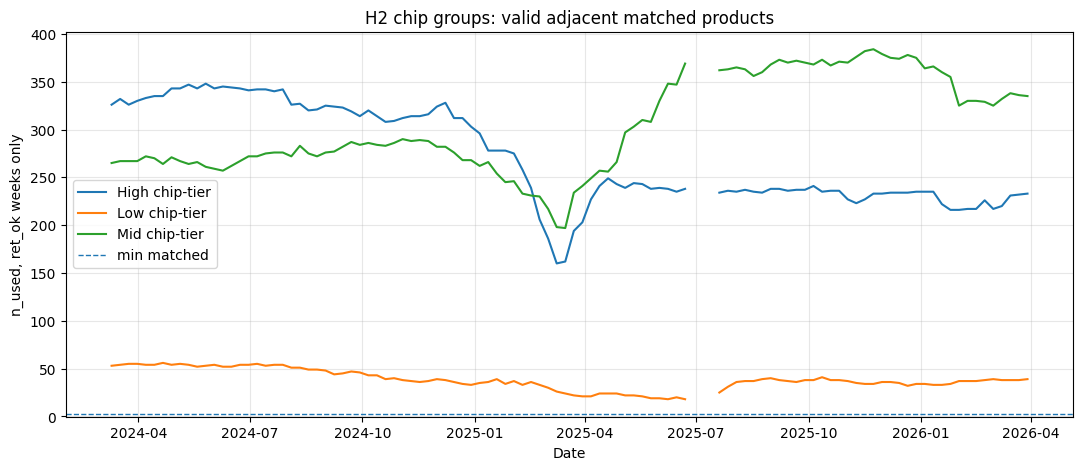

[saved plot] output_pic\H2_chain-level_weekly_log_return_distribution.png


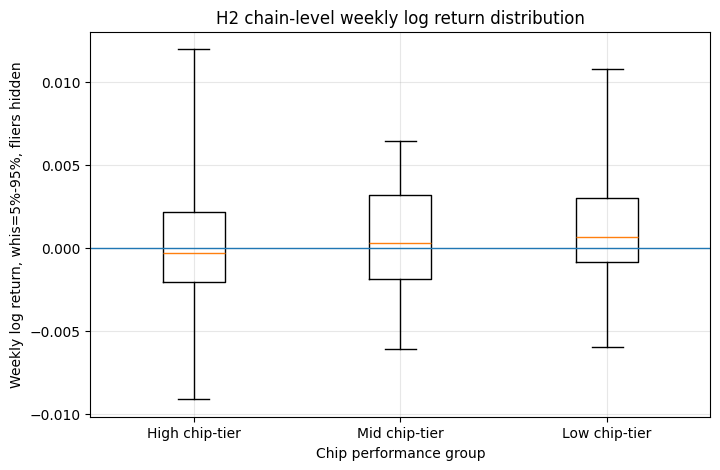

extra EDA saved to: outputs


In [16]:
mkt_w = pd.read_csv('./outputs/mkt_w.csv')
mkt_w["Date"] = pd.to_datetime(mkt_w["Date"])
mkt_w = mkt_w.set_index("Date").sort_index()
mkt_w.index = mkt_w.index.normalize()

MKT_COLS = ["btc_krw_ret", "fx_ret"]
CHIP_ORDER = [g for g in ["high", "mid", "low"] if g in ret_chip_w.columns]


def common_sample(ret_df, cols, name):
    dat = ret_df[cols].join(mkt_w[MKT_COLS], how="inner")
    return {
        "sample": name,
        "week_n": len(dat),
        "complete_n": dat.dropna().shape[0],
        "hw_nonnull_min": int(dat[cols].notna().sum().min()),
        "mkt_nonnull_min": int(dat[MKT_COLS].notna().sum().min()),
    }


sample_check = pd.DataFrame([
    common_sample(ret_all_w, ["GPU_ALL"], "H1_GPU_vs_BTC"),
    common_sample(ret_chip_w, CHIP_ORDER, "H2_chip_groups"),
    common_sample(ret_all_w, ["GPU_ALL", "CPU_ALL", "RAM_ALL"], "H3_parts"),
])

print("가설별 공통 표본 수")
display(sample_check)


def corr_with_mkt(ret_df, cols):
    dat = ret_df[cols].join(mkt_w[MKT_COLS], how="inner").dropna()
    return dat[cols + MKT_COLS].corr()


corr_all = corr_with_mkt(ret_all_w, ["GPU_ALL", "CPU_ALL", "RAM_ALL"])
corr_chip = corr_with_mkt(ret_chip_w, CHIP_ORDER)

print("H1/H3 return correlation")
display(corr_all.round(3))
print("H2 chip return correlation")
display(corr_chip.round(3))


def ols_eda(ret_df, cols):
    rows = []
    for col in cols:
        dat = ret_df[[col]].join(mkt_w[MKT_COLS], how="inner").dropna()
        if len(dat) < 10:
            continue
        y = dat[col].to_numpy(float)
        X = np.column_stack([
            np.ones(len(dat)),
            dat["btc_krw_ret"].to_numpy(float),
            dat["fx_ret"].to_numpy(float),
        ])
        b = np.linalg.lstsq(X, y, rcond=None)[0]
        yhat = X @ b
        ss_res = ((y - yhat) ** 2).sum()
        ss_tot = ((y - y.mean()) ** 2).sum()
        rows.append({
            "target": col,
            "n": len(dat),
            "beta_btc_krw": b[1],
            "beta_fx": b[2],
            "r2": np.nan if ss_tot == 0 else 1 - ss_res / ss_tot,
        })
    return pd.DataFrame(rows)


beta_all = ols_eda(ret_all_w, ["GPU_ALL", "CPU_ALL", "RAM_ALL"])
beta_chip = ols_eda(ret_chip_w, CHIP_ORDER)
beta_eda = pd.concat([beta_all.assign(block="H1_H3"), beta_chip.assign(block="H2")], ignore_index=True)

print("환율 통제 포함 단순 사전 회귀계수")
display(beta_eda.round(4))


def idx_health(index_df, name):
    temp = index_df.copy()
    temp["date"] = pd.to_datetime(temp["date"])
    temp = temp[temp["date"] != temp["date"].min()]

    rows = []
    for group, sub in temp.groupby("group"):
        valid = sub[sub["ret_ok"]]
        idx_nonnull = sub["index_valid"].dropna()
        rows.append({
            "group": group,
            "valid_ret_n": int(valid.shape[0]),
            "bridge_n": int(sub["bridge"].sum()),
            "gap_n": int((~sub["ret_ok"] & ~sub["bridge"]).sum()),
            "median_valid_n_used": valid["n_used"].median(),
            "min_valid_n_used": valid["n_used"].min(),
            "max_abs_ret": valid["ret_w"].dropna().abs().max(),
            "final_index": idx_nonnull.iloc[-1] if len(idx_nonnull) else np.nan,
            "block": name,
        })
    return pd.DataFrame(rows)


health = pd.concat([
    idx_health(idx_all, "all"),
    idx_health(idx_chip, "chip"),
    idx_health(idx_vram, "vram"),
], ignore_index=True)

print("지수 산출 안정성 요약")
display(health.round(3))


def q(x, p):
    return x.quantile(p)


panel_eda = (
    panel_gpu.groupby("chip_perf_group")
    .agg(
        obs_n=("gpu_log_return", "count"),
        product_n=("row_id", "nunique"),
        zero_share=("gpu_log_return", lambda x: np.mean(np.isclose(x.dropna(), 0))),
        mean_ret=("gpu_log_return", "mean"),
        std_ret=("gpu_log_return", "std"),
        p05=("gpu_log_return", lambda x: q(x, 0.05)),
        p25=("gpu_log_return", lambda x: q(x, 0.25)),
        p50=("gpu_log_return", "median"),
        p75=("gpu_log_return", lambda x: q(x, 0.75)),
        p95=("gpu_log_return", lambda x: q(x, 0.95)),
    )
    .reset_index()
)

print("GPU 제품 단위 주간 수익률 분포: 표로만 진단")
display(panel_eda.round(4))

chip_ret_long = (
    ret_chip_w[CHIP_ORDER]
    .melt(var_name="group", value_name="ret")
    .dropna()
)

chain_eda = (
    chip_ret_long.groupby("group")
    .agg(
        week_n=("ret", "count"),
        mean_ret=("ret", "mean"),
        std_ret=("ret", "std"),
        p05=("ret", lambda x: q(x, 0.05)),
        p50=("ret", "median"),
        p95=("ret", lambda x: q(x, 0.95)),
    )
    .reset_index()
)

print("H2 검정용 chain-level 주간 수익률 분포")
display(chain_eda.round(4))

plt.figure(figsize=(13, 5))
for group, sub in idx_chip.groupby("group"):
    sub = sub.sort_values("date").copy()
    sub["date"] = pd.to_datetime(sub["date"])
    y = sub["n_used"].where(sub["ret_ok"])
    plt.plot(sub["date"], y, label=f"{CHIP_LABEL.get(group, group)}")
plt.axhline(MIN_GRP, linestyle="--", linewidth=1, label="min matched")
plt.title("H2 chip groups: valid adjacent matched products")
plt.xlabel("Date")
plt.ylabel("n_used, ret_ok weeks only")
plt.legend()
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

vals = [ret_chip_w[g].dropna().to_numpy(float) for g in CHIP_ORDER]
labels = [CHIP_LABEL.get(g, g) for g in CHIP_ORDER]

plt.figure(figsize=(8, 5))
plt.boxplot(vals, tick_labels=labels, whis=(5, 95), showfliers=False)
plt.axhline(0, linewidth=1)
plt.title("H2 chain-level weekly log return distribution")
plt.xlabel("Chip performance group")
plt.ylabel("Weekly log return, whis=5%-95%, fliers hidden")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

sample_check.to_csv(OUT / "eda_sample.csv", index=False)
corr_all.to_csv(OUT / "eda_corr_all.csv")
corr_chip.to_csv(OUT / "eda_corr_chip.csv")
beta_eda.to_csv(OUT / "eda_beta.csv", index=False)
health.to_csv(OUT / "eda_health.csv", index=False)
panel_eda.to_csv(OUT / "eda_panel_gpu.csv", index=False)
chain_eda.to_csv(OUT / "eda_chain_chip.csv", index=False)

print("extra EDA saved to:", OUT)

<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>시계열 EDA 추가: 계절성 및 분기별 수익률 분포</mark></b></span><br><br>

<b>[왜 추가하는가]</b><br>
하드웨어 가격은 암호화폐 가격 외에도 연말 프로모션, 신제품 출시 주기, 특정 분기의 교체 수요에 영향을 받을 수 있다. 따라서 회귀분석 전 단계에서 월별·분기별 수익률 분포를 확인해, 특정 달이나 분기에 가격 변동이 몰리는지를 진단한다.<br><br>

<b>[해석 원칙]</b><br>
이 결과는 본검정의 통제변수가 아니라 <b>계절성 및 제품주기 한계 진단용 EDA</b>이다. 특정 월·분기에서 변동성이 크면, 보고서에서는 신제품 주기나 프로모션 효과가 남아 있을 수 있음을 한계로 인정한다.
</div>

monthly return summary, all hardware


,group,month,n,mean_ret,std_ret,median_ret,block
0,CPU_ALL,1,8,0.0048,0.0013,0.0048,all
1,CPU_ALL,2,8,-0.0036,0.0121,0.0007,all
2,CPU_ALL,3,14,-0.0012,0.0039,-0.0001,all
3,CPU_ALL,4,8,-0.0042,0.0048,-0.0048,all
4,CPU_ALL,5,8,-0.0018,0.0050,-0.0024,all
5,CPU_ALL,6,9,-0.0004,0.0041,0.0005,all
6,CPU_ALL,7,6,-0.0003,0.0015,-0.0005,all
7,CPU_ALL,8,9,-0.0003,0.0030,-0.0003,all
8,CPU_ALL,9,9,-0.0002,0.0055,-0.0005,all
9,CPU_ALL,10,8,-0.0020,0.0066,-0.0005,all


quarterly return summary, chip groups


,group,quarter,n,mean_ret,std_ret,median_ret,block
0,high,1,30,0.0057,0.0168,0.0020,chip
1,high,2,25,-0.0036,0.0039,-0.0028,chip
2,high,3,24,-0.0007,0.0025,-0.0002,chip
3,high,4,26,0.0013,0.0030,0.0006,chip
4,low,1,30,0.0063,0.0162,0.0026,chip
5,low,2,25,0.0002,0.0036,0.0002,chip
6,low,3,24,0.0001,0.0030,0.0004,chip
7,low,4,26,0.0015,0.0051,0.0004,chip
8,mid,1,30,0.0063,0.0164,0.0037,chip
9,mid,2,25,-0.0017,0.0028,-0.0012,chip


[saved plot] output_pic\Monthly_distribution_of_GPU_weekly_returns.png


<Figure size 1000x400 with 0 Axes>

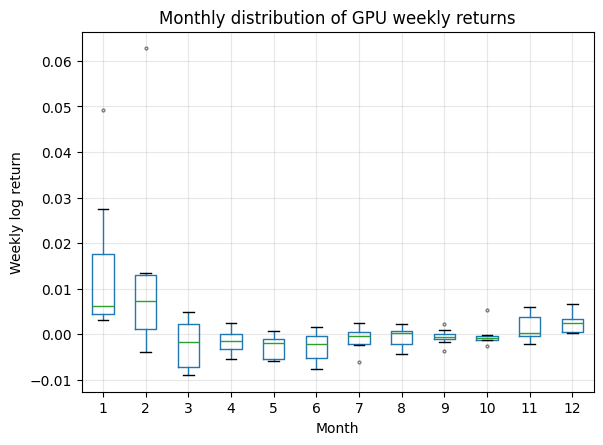

[saved plot] output_pic\Quarterly_distribution_of_chip-group_weekly_returns.png


<Figure size 1000x400 with 0 Axes>

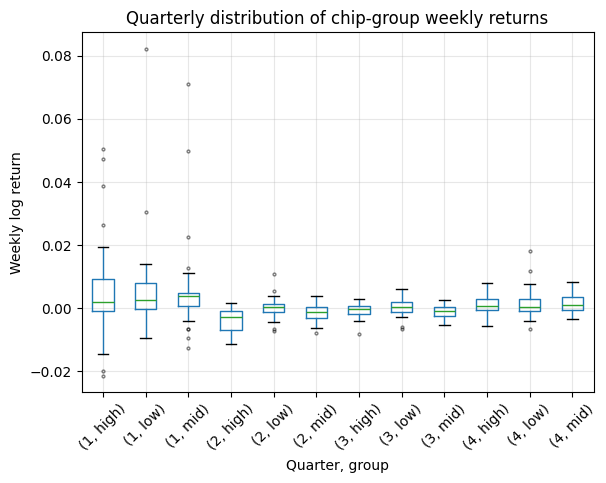

In [17]:
def season_summary(ret_df, cols, block):
    long = (
        ret_df[cols]
        .reset_index()
        .melt(id_vars="date", value_vars=cols, var_name="group", value_name="ret")
        .dropna()
    )
    long["date"] = pd.to_datetime(long["date"])
    long["month"] = long["date"].dt.month
    long["quarter"] = long["date"].dt.quarter

    month = (
        long.groupby(["group", "month"])
        .agg(
            n=("ret", "count"),
            mean_ret=("ret", "mean"),
            std_ret=("ret", "std"),
            median_ret=("ret", "median"),
        )
        .reset_index()
        .assign(block=block)
    )

    quarter = (
        long.groupby(["group", "quarter"])
        .agg(
            n=("ret", "count"),
            mean_ret=("ret", "mean"),
            std_ret=("ret", "std"),
            median_ret=("ret", "median"),
        )
        .reset_index()
        .assign(block=block)
    )

    return long, month, quarter


season_all_long, season_all_month, season_all_quarter = season_summary(
    ret_all_w, ["GPU_ALL", "CPU_ALL", "RAM_ALL"], "all"
)
season_chip_long, season_chip_month, season_chip_quarter = season_summary(
    ret_chip_w, CHIP_ORDER, "chip"
)

print("monthly return summary, all hardware")
display(season_all_month.round(4))
print("quarterly return summary, chip groups")
display(season_chip_quarter.round(4))

season_all_month.to_csv(OUT / "season_all_month.csv", index=False)
season_all_quarter.to_csv(OUT / "season_all_quarter.csv", index=False)
season_chip_month.to_csv(OUT / "season_chip_month.csv", index=False)
season_chip_quarter.to_csv(OUT / "season_chip_quarter.csv", index=False)

plt.figure(figsize=(10, 4))
season_all_long[season_all_long["group"] == "GPU_ALL"].boxplot(
    column="ret",
    by="month",
    flierprops={"marker": "o", "markersize": 2, "alpha": 0.5},
)
plt.title("Monthly distribution of GPU weekly returns")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("Weekly log return")
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

plt.figure(figsize=(10, 4))
season_chip_long.boxplot(
    column="ret",
    by=["quarter", "group"],
    flierprops={"marker": "o", "markersize": 2, "alpha": 0.5},
)
plt.title("Quarterly distribution of chip-group weekly returns")
plt.suptitle("")
plt.xlabel("Quarter, group")
plt.ylabel("Weekly log return")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
save_plot(); plt.show()

In [24]:
print("[Hypo 1] GPU 전체 가격과 BTC-KRW 가격의 공변동")
print("시각화용 index: idx_all_w['GPU_ALL']")
print("검정용 hardware return: ret_all_w['GPU_ALL']  # bridge 제외, 인접 주 기준")
print("기본 BTC 변수: mkt_w['btc_krw_ret']")
print("환율 통제 변수: mkt_w['fx_ret']")
print()

print("[Hypo 2] GPU 성능군별 BTC-KRW 민감도 차이")
print("본분석 index: idx_chip_w[['high', 'mid', 'low']]  # chip 기준")
print("본분석 return: ret_chip_w[['high', 'mid', 'low']]  # bridge 제외, 인접 주 기준")
print("보조분석 index: idx_vram_w[['high', 'mid', 'low']]  # VRAM proxy")
print("제품 단위 panel: panel_gpu")
print()

print("[Hypo 3] GPU / CPU / RAM 간 BTC-KRW 영향 크기 비교")
print("시각화용 index: idx_all_w[['GPU_ALL', 'CPU_ALL', 'RAM_ALL']]")
print("검정용 return: ret_all_w[['GPU_ALL', 'CPU_ALL', 'RAM_ALL']]  # bridge 제외, 인접 주 기준")

[Hypo 1] GPU 전체 가격과 BTC-KRW 가격의 공변동
시각화용 index: idx_all_w['GPU_ALL']
검정용 hardware return: ret_all_w['GPU_ALL']  # bridge 제외, 인접 주 기준
기본 BTC 변수: mkt_w['btc_krw_ret']
환율 통제 변수: mkt_w['fx_ret']

[Hypo 2] GPU 성능군별 BTC-KRW 민감도 차이
본분석 index: idx_chip_w[['high', 'mid', 'low']]  # chip 기준
본분석 return: ret_chip_w[['high', 'mid', 'low']]  # bridge 제외, 인접 주 기준
보조분석 index: idx_vram_w[['high', 'mid', 'low']]  # VRAM proxy
제품 단위 panel: panel_gpu

[Hypo 3] GPU / CPU / RAM 간 BTC-KRW 영향 크기 비교
시각화용 index: idx_all_w[['GPU_ALL', 'CPU_ALL', 'RAM_ALL']]
검정용 return: ret_all_w[['GPU_ALL', 'CPU_ALL', 'RAM_ALL']]  # bridge 제외, 인접 주 기준


<div style="line-height: 1.8;">
<br>
<span style="font-size: 24px;"><b><mark>EDA final-clean 실행결과 해석</mark></b></span><br><br>

<b>[표본 안정성]</b><br>
최종 EDA 결과에서 Hypo 1용 전체 GPU-BTC 표본은 109개 주 중 105개 주가 완전 표본으로 남았다. H2 chip 성능군 표본도 동일하게 109개 주 중 105개 주가 유효했고, 시장변수는 최소 108개 주가 확보되어 GPU 지수와 시장변수 정렬 자체가 표본 손실의 주원인은 아니었다. 전체 Chain Matched 지수는 GPU, CPU, RAM 모두 109개 step 중 106개가 valid였고 return 기준 105개 주를 사용했다.<br><br>
<b>[Chain Matched Index 품질]</b><br>
전체 지수의 median matched product 수는 GPU 711개, CPU 209개, RAM 1156개였고, trim 이후 실제 사용 제품 수의 median은 GPU 638개, CPU 187개, RAM 1034개였다. 성능군별로는 high 269개, mid 316개, low 43개의 median matched product가 확보되었다. 따라서 high와 mid는 충분히 안정적이지만 low는 제품 수가 작아 이후 H2에서 기준항으로 쓰기보다 해석상 주의해야 하는 그룹으로 보았다.<br><br>
<b>[Bridge/gap 처리 확인]</b><br>
각 성능군은 105개 valid return과 1개 bridge step, 3개 gap step을 가졌다. bridge_adj_ratio는 high 0.0037, mid 0.0032, low 0.0000 수준이라 bridge 구간이 검정용 수익률에 크게 섞였다고 보기 어렵다. 즉, 검정용 return은 관측 가능한 인접 주 가격 변화에 기반한다는 전처리 원칙이 유지되었다.<br><br>
<b>[기초 상관과 beta]</b><br>
전체 GPU 수익률과 BTC-KRW 수익률의 단순 상관은 -0.2216이었고, CPU는 0.0510, RAM은 -0.0951이었다. GPU의 단순 BTC beta도 -0.0404로 양의 민감도는 보이지 않았다. chip 성능군별 BTC 상관도 high -0.1716, mid -0.2278, low -0.1992로 모두 음수였고, beta는 high -0.0341, mid -0.0427, low -0.0365였다. 따라서 EDA 단계만 보면 BTC 상승이 GPU 가격 상승으로 바로 이어진다는 강한 양의 패턴은 없다.<br><br>
<b>[Trim/no-trim 점검]</b><br>
main trimmed return과 no-trim return의 상관은 GPU_ALL 0.9824, chip high 0.9811, chip mid 0.9794로 매우 높았다. 다만 chip low는 0.8691, VRAM low는 0.7762로 낮아 소표본 그룹에서는 극단값 처리에 더 민감했다. 그래서 main 분석은 5% trim 지수를 유지하되, Hypo 1·2에서 no-trim robustness를 별도로 수행했다.<br><br>
<b>[계절성 점검]</b><br>
전체 GPU의 분기 평균 수익률은 Q1 0.00617, Q2 -0.00243, Q3 -0.00081, Q4 0.00126이었다. chip 성능군도 Q1에서 high 0.00570, mid 0.00633, low 0.00628로 상대적으로 높고 Q2에서 약해지는 패턴이 보였다. 이는 신제품·프로모션·수요 주기 가능성을 시사하지만, 본 검정에서 특정 출시일 dummy를 임의로 넣기보다는 제품구성 proxy와 robustness로 방어하는 것이 더 안전하다.<br><br>
<b>[EDA 결론]</b><br>
최종 EDA는 데이터가 가설검정에 사용할 만큼 안정적이라는 점을 확인했다. 동시에 BTC와 GPU 사이의 단순 관계는 강한 양의 관계가 아니며, low 그룹은 표본 수가 작아 H2에서 해석상 주의가 필요하다는 점도 확인했다. 따라서 후속 분석은 단순 상관이 아니라 시차, 환율, NVDA, 자기시차, 제품구성 변화를 통제한 회귀와 robustness 중심으로 진행하는 것이 타당하다.

</div>